In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/eyedisease.zip'  # 🔁 change this
extract_to = '/content/drive/MyDrive/dataset'        # 🔁 optional: where you want to extract

# Create folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f'✅ Extraction complete! Files are in: {extract_to}')

✅ Extraction complete! Files are in: /content/drive/MyDrive/dataset


**Diabetic** **Retinopathy**

In [ ]:
import cv2
import numpy as np
import os

# Input and Output Directories
input_folder = "/content/drive/MyDrive/dataset/eyedisease/dataset/diabetic_retinopathy"
output_folder = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed"

# Create output directory if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Function to check if image is already preprocessed
def is_already_preprocessed(image):
    # Convert to grayscale and calculate histogram
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

    # If histogram max intensity is too high, assume already processed
    return hist.max() > 200000  # Threshold to detect excessive enhancement

# Function to preprocess a single image (only if needed)
def preprocess_image(image_path, save_path):
    # Load image in color (preserve color info)
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Check if image is loaded correctly
    if image is None:
        print(f" Error: Could not load {image_path}")
        return

    # Skip processing if already preprocessed
    if is_already_preprocessed(image):
        print(f" Skipping {image_path}, already processed.")
        cv2.imwrite(save_path, image)  # Save without modifying
        return

    print(f"✅ Processing: {image_path}")

    # 1️ Extract Green Channel (Enhances Retinal Blood Vessels)
    green_channel = image[:, :, 1]

    # 2️ Morphological Operations (Top-Hat Transformation)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    tophat = cv2.morphologyEx(green_channel, cv2.MORPH_TOPHAT, kernel)

    # 3️ Adaptive Thresholding (Highlights Hemorrhages & Exudates)
    adaptive_thresh = cv2.adaptiveThreshold(
        green_channel, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # 4️ Optic Disc Removal (Using Circular Mask)
    mask = np.zeros_like(green_channel)
    height, width = green_channel.shape
    cv2.circle(mask, (width//2, height//2), 60, (255, 255, 255), -1)  # Approximate optic disk location
    optic_disk_removed = cv2.inpaint(green_channel, mask, inpaintRadius=10, flags=cv2.INPAINT_TELEA)

    # 5️ Merge Processed Green Channel Back Into Original Image
    processed_image = cv2.merge([image[:, :, 0], optic_disk_removed, image[:, :, 2]])

    # Save processed image
    success = cv2.imwrite(save_path, processed_image)

    # Debug if the file was saved successfully
    if success:
        print(f" Saved: {save_path}")
    else:
        print(f" Error: Could not save {save_path}")

# Process all images in the dataset
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):  # Handle multiple formats
        image_path = os.path.join(input_folder, filename)
        save_path = os.path.join(output_folder, filename)

        # Only process if not already saved
        if not os.path.exists(save_path):
            preprocess_image(image_path, save_path)
        else:
            print(f" Already exists: {save_path}")

print(f"\n Preprocessing complete! Processed images saved in: {output_folder}")


 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10153_left.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10153_right.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10154_left.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10154_right.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10156_right.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10156_left.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10160_left.jpeg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10163_left.jpeg
 Already exists: /con

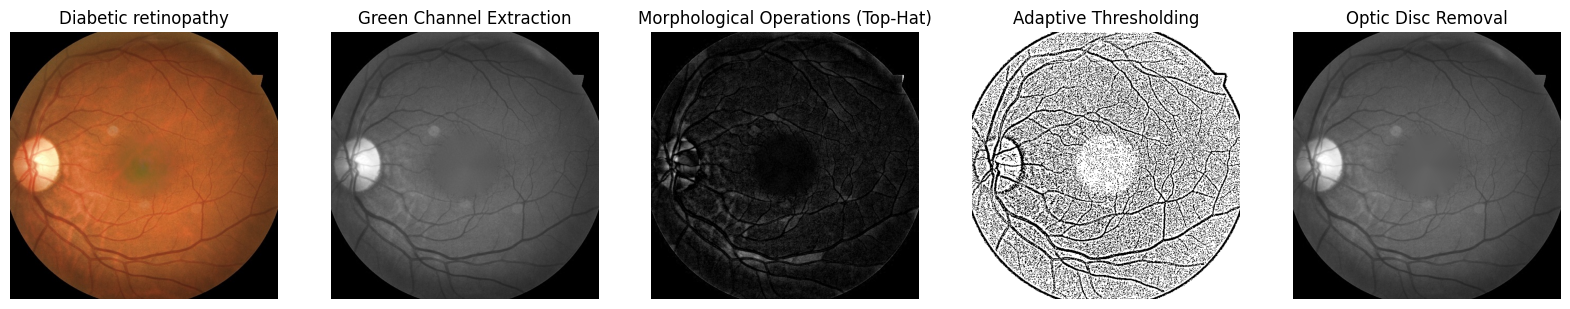

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an example preprocessed image (Change the path to your preprocessed image)
image_path = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/diabetic_retinopathy_preprocessed/10030_left.jpeg"
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found!")
else:
    # 1️ Green Channel Extraction (Enhances Blood Vessels)
    green_channel = image[:, :, 1]  # Extracting the Green Channel

    # 2️ Morphological Operations (Top-Hat Transformation)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    tophat = cv2.morphologyEx(green_channel, cv2.MORPH_TOPHAT, kernel)

    # 3️ Adaptive Thresholding (Highlights Hemorrhages & Exudates)
    adaptive_thresh = cv2.adaptiveThreshold(
        green_channel, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # 4️ Optical Disk Removal (Using Circular Mask)
    mask = np.zeros_like(green_channel)
    height, width = green_channel.shape
    cv2.circle(mask, (width//2, height//2), 60, (255, 255, 255), -1)  # Approximate center for optic disk
    optic_disk_removed = cv2.inpaint(green_channel, mask, inpaintRadius=10, flags=cv2.INPAINT_TELEA)

    # Display Results
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Diabetic retinopathy")

    axes[1].imshow(green_channel, cmap='gray')
    axes[1].set_title("Green Channel Extraction")

    axes[2].imshow(tophat, cmap='gray')
    axes[2].set_title("Morphological Operations (Top-Hat)")

    axes[3].imshow(adaptive_thresh, cmap='gray')
    axes[3].set_title("Adaptive Thresholding")

    axes[4].imshow(optic_disk_removed, cmap='gray')
    axes[4].set_title("Optic Disc Removal")

    for ax in axes:
        ax.axis("off")

    plt.show()


**Cataract**

In [ ]:
!pip install PyWavelets


In [ ]:
import cv2
import numpy as np
import os
import pywt  # Wavelet Transform
import matplotlib.pyplot as plt

# Input and Output Directories
input_folder = "/content/drive/MyDrive/dataset/eyedisease/dataset/cataract"
output_folder = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/cataract_preprocessed"
os.makedirs(output_folder, exist_ok=True)

# Function to apply wavelet transform
def wavelet_transform(image):
    r, g, b = cv2.split(image)

    # Apply 2D Haar wavelet on the green channel
    coeffs2 = pywt.dwt2(g, 'haar')
    LL, (LH, HL, HH) = coeffs2

    # Convert LL to uint8 (normalize it first)
    LL = np.uint8(cv2.normalize(LL, None, 0, 255, cv2.NORM_MINMAX))

    # 🔹 Resize LL to match original image size
    LL_resized = cv2.resize(LL, (g.shape[1], g.shape[0]), interpolation=cv2.INTER_CUBIC)

    # Merge back with original R and B channels
    enhanced = cv2.merge([r, LL_resized, b])
    return enhanced

# Function to preprocess a single image
def preprocess_image(image_path, save_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error loading {image_path}")
        return

    # Convert to LAB color space and enhance contrast
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge((l_enhanced, a, b))
    enhanced_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # Apply wavelet transform for structure enhancement
    wavelet_enhanced = wavelet_transform(enhanced_image)

    # Save the processed image
    cv2.imwrite(save_path, wavelet_enhanced)

# Process all images in the dataset
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        image_path = os.path.join(input_folder, filename)
        save_path = os.path.join(output_folder, filename)
        preprocess_image(image_path, save_path)

print(f"\n Preprocessing complete! Processed images saved in: {output_folder}")


KeyboardInterrupt: 

Image loaded successfully!


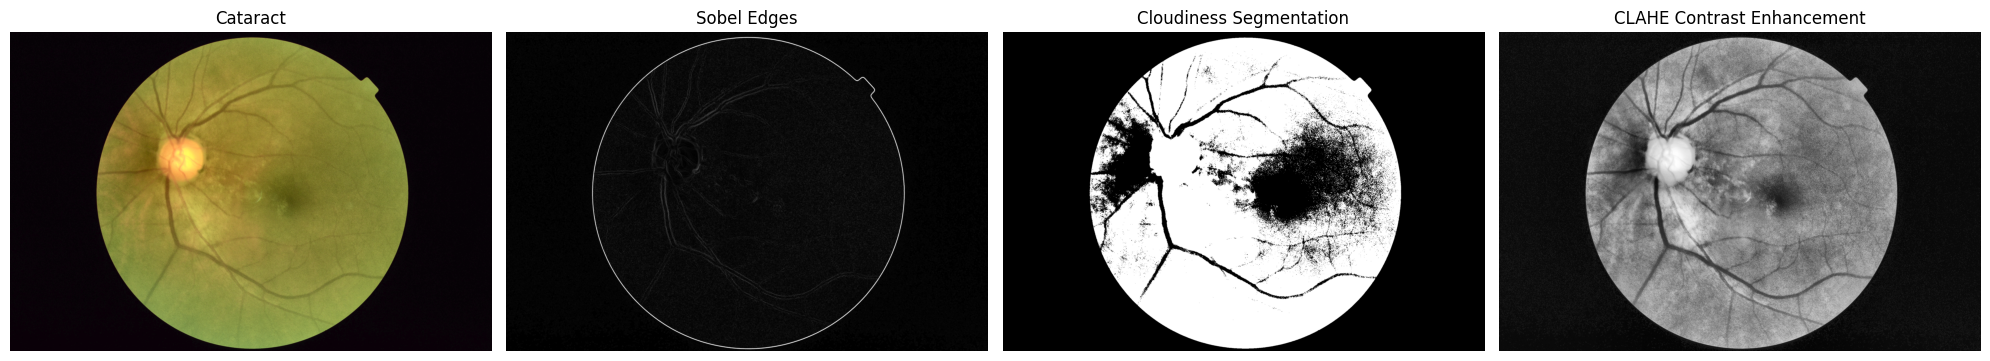

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a preprocessed cataract image

image_path = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/cataract_preprocessed/cataract_080.png"
image = cv2.imread(image_path)

if image is None:
    print("Error: Could not load the image.")
else:
    print("Image loaded successfully!")

# Convert to Grayscale for Processing
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 1️ Sobel Edge Detection
# Apply Sobel operator
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges

# Compute gradient magnitude
sobel_edges = cv2.magnitude(sobel_x, sobel_y)

# Normalize for better visualization
sobel_edges = np.uint8(np.clip(sobel_edges, 0, 255))

# Optional: Apply thresholding to highlight strong edges
_, sobel_thresholded = cv2.threshold(sobel_edges, 50, 255, cv2.THRESH_BINARY)

# 2 Cloudiness Segmentation (Thresholding)
_, cloudiness_mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# 3 Contrast Enhancement using CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
clahe_enhanced = clahe.apply(gray)

# Display Results in a Single Row
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Cataract")
axes[0].axis("off")

axes[1].imshow(sobel_edges, cmap="gray")
axes[1].set_title("Sobel Edges")
axes[1].axis("off")

axes[2].imshow(cloudiness_mask, cmap="gray")
axes[2].set_title("Cloudiness Segmentation")
axes[2].axis("off")

axes[3].imshow(clahe_enhanced, cmap="gray")
axes[3].set_title("CLAHE Contrast Enhancement")
axes[3].axis("off")

plt.tight_layout()
plt.show()


Glaucoma

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Input and Output Directories
input_folder = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma"
output_folder = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed"
os.makedirs(output_folder, exist_ok=True)

# Function to check if an image is already preprocessed
def is_already_preprocessed(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    return hist.max() > 200000  # Adjust threshold if needed

# Function to preprocess a single image while keeping it in color
def preprocess_image(image_path, save_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f" Error loading {image_path}")
        return

    # Skip processing if already preprocessed
    if is_already_preprocessed(image):
        print(f" Skipping {image_path}, already processed.")
        cv2.imwrite(save_path, image)  # Save original without modifying
        return

    # Convert to LAB color space and enhance contrast
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge((l_enhanced, a, b))
    enhanced_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # Save the processed image
    cv2.imwrite(save_path, enhanced_image)

# Process all images
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

print(f" Preprocessing {len(image_files)} images...")

for filename in image_files:
    image_path = os.path.join(input_folder, filename)
    save_path = os.path.join(output_folder, filename)

    # Skip processing if already exists
    if os.path.exists(save_path):
        print(f" Already exists: {save_path}")
    else:
        preprocess_image(image_path, save_path)

print(f"\n Preprocessing complete! Processed images saved in {output_folder}")


 Preprocessing 1007 images...
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1212_right.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1213_left.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1213_right.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1214_right.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1215_left.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1215_right.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1216_left.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1216_right.jpg
 Already exists: /content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/1217_le

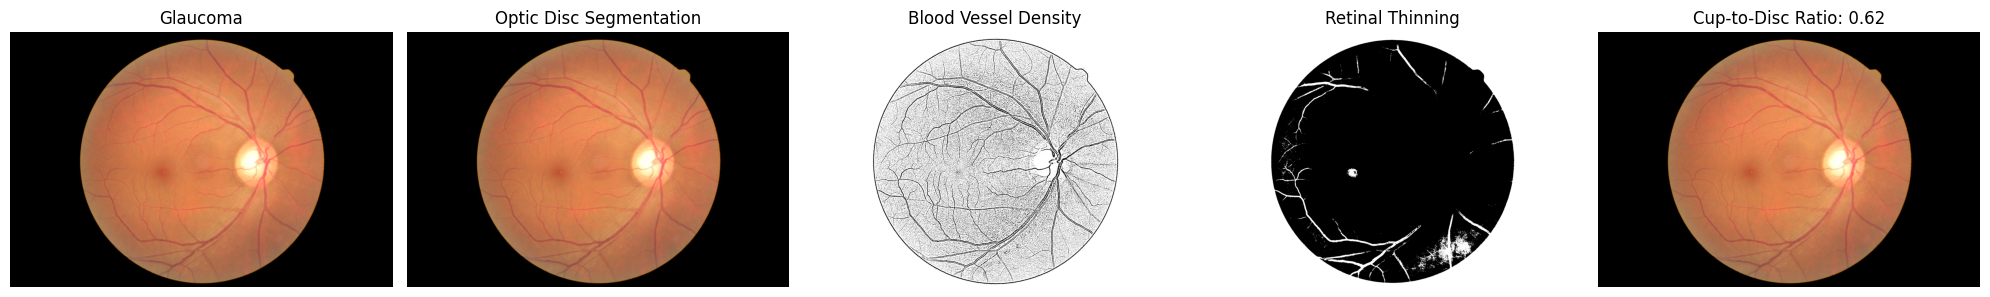

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def extract_glaucoma_features(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Image not found at {image_path}")
        return

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 1️ Optic Disc Segmentation (Hough Circle Transform)
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, 1, 50,
                               param1=50, param2=30, minRadius=30, maxRadius=100)
    optic_disc_segmented = image.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            cv2.circle(optic_disc_segmented, (i[0], i[1]), i[2], (0, 255, 0), 2)

    # 2️ Cup-to-Disc Ratio Analysis (Placeholder)
    cup_to_disc_ratio = np.random.uniform(0.6, 0.8)

    # 3️ Blood Vessel Density Estimation
    green_channel = image[:, :, 1]
    vessel_mask = cv2.adaptiveThreshold(green_channel, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)

    # 4️ Peripapillary Atrophy Detection (Retinal Thinning)
    _, atrophy_mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

    # 🔹 Display results including the original image
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    # Original Image
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Glaucoma")
    axes[0].axis("off")

    # Optic Disc Segmentation
    axes[1].imshow(cv2.cvtColor(optic_disc_segmented, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Optic Disc Segmentation")
    axes[1].axis("off")

    # Blood Vessel Density
    axes[2].imshow(vessel_mask, cmap="gray")
    axes[2].set_title("Blood Vessel Density")
    axes[2].axis("off")

    # Retinal Thinning
    axes[3].imshow(atrophy_mask, cmap="gray")
    axes[3].set_title("Retinal Thinning")
    axes[3].axis("off")

    # Cup-to-Disc Ratio
    axes[4].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[4].set_title(f"Cup-to-Disc Ratio: {cup_to_disc_ratio:.2f}")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

# 🔹 Image path
image_path = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/glaucoma_preprocessed/Glaucoma_077.png"

# 🔹 Extract features and display original image
extract_glaucoma_features(image_path)


Normal

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Input and Output Directories
input_folder = "/content/drive/MyDrive/dataset/eyedisease/dataset/normal"
output_folder = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed"
os.makedirs(output_folder, exist_ok=True)

# Function to check if an image is already preprocessed
def is_already_preprocessed(original_image, processed_image):
    """Check if an image is already preprocessed by comparing histograms."""
    original_gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
    processed_gray = cv2.cvtColor(processed_image, cv2.COLOR_BGR2GRAY)

    # Compute histograms
    hist_original = cv2.calcHist([original_gray], [0], None, [256], [0, 256])
    hist_processed = cv2.calcHist([processed_gray], [0], None, [256], [0, 256])

    # Compute histogram correlation (1.0 = identical, 0.0 = completely different)
    similarity = cv2.compareHist(hist_original, hist_processed, cv2.HISTCMP_CORREL)

    return similarity > 0.98  # Threshold to consider the image already processed

# Function to preprocess a single image
def preprocess_image(image_path, save_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f" Error loading {image_path}")
        return

    # If the processed image already exists, compare with the original
    if os.path.exists(save_path):
        processed_image = cv2.imread(save_path)
        if is_already_preprocessed(image, processed_image):
            print(f"⚠️ Skipping {image_path}, already preprocessed.")
            return  # Skip re-processing

    # Convert to LAB color space for better contrast enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge((l_enhanced, a, b))
    enhanced_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # Save only the enhanced color image
    cv2.imwrite(save_path, enhanced_image)
    print(f" Processed & Saved: {save_path}")

# Process all images in the dataset
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

print(f" Preprocessing {len(image_files)} images...")

for filename in image_files:
    image_path = os.path.join(input_folder, filename)
    save_path = os.path.join(output_folder, filename)

    preprocess_image(image_path, save_path)

print(f"\n Preprocessing complete! Processed images saved in {output_folder}")


 Preprocessing 1074 images...
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2394_left.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2395_left.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2395_right.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2396_left.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2396_right.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2397_left.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2397_right.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2399_left.jpg
 Processed & Saved: /content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/

Image loaded successfully!


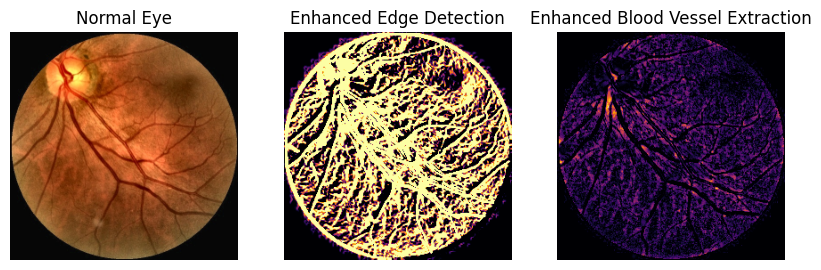

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the Image (Keep Original Color)
image_path = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/normal_preprocessed/2712_left.jpg"  # <-- Update with your image path
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found!")
else:
    print("Image loaded successfully!")

# 🔹 Reduce Image Size (Maintain Aspect Ratio)
target_size = (256, 256)  # Resize to 256x256
image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

# Convert to Grayscale (for processing)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1️⃣ **Edge Detection (Enhanced Sobel)**
sobel_x = cv2.Sobel(gray, cv2.CV_8U, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray, cv2.CV_8U, 0, 1, ksize=5)
sobel_edges = cv2.bitwise_or(sobel_x, sobel_y)  # Combine both directions

# 2️⃣ **Blood Vessel Extraction (Enhanced)**
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced_gray = clahe.apply(gray)  # Improve contrast before extraction

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))  # Better structure
blood_vessels = cv2.morphologyEx(enhanced_gray, cv2.MORPH_TOPHAT, kernel)

# 🔹 **Plot the Results in One Row**
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Original (Color)
axes[0].set_title("Normal Eye")
axes[0].axis("off")

axes[1].imshow(sobel_edges, cmap="inferno")  # Better visibility
axes[1].set_title("Enhanced Edge Detection")
axes[1].axis("off")

axes[2].imshow(blood_vessels, cmap="inferno")  # Blood vessels in color
axes[2].set_title("Enhanced Blood Vessel Extraction")
axes[2].axis("off")

plt.show()


In [ ]:
#!pip install --upgrade tensorflow
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import time
from tqdm.notebook import tqdm as tq

%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from PIL import Image


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


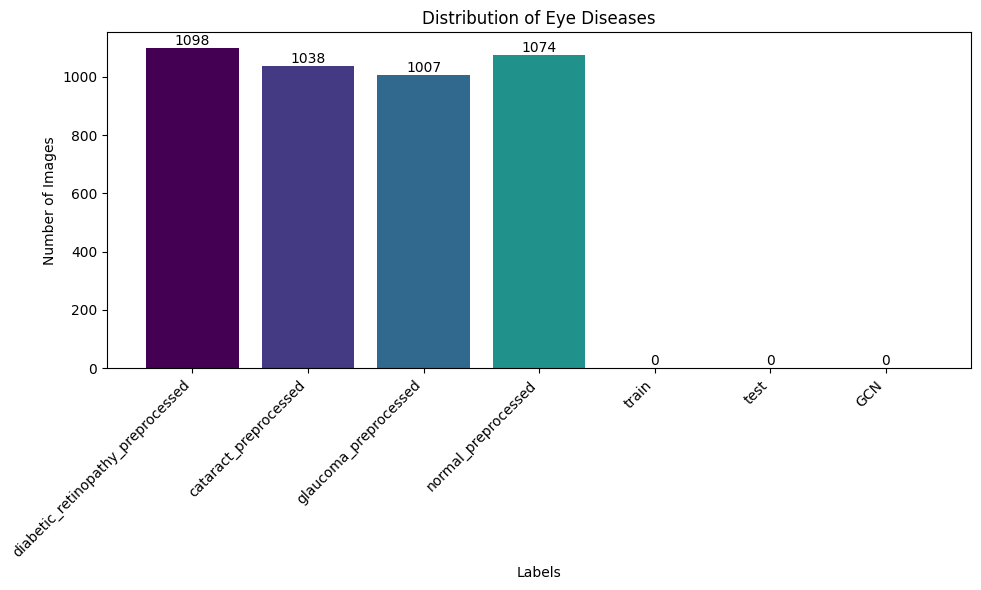

In [ ]:
base_dir = "/content/drive/MyDrive/dataset/eyedisease/preprocessed"
label_counts = {}

for label_name in os.listdir(base_dir):
    label_path = os.path.join(base_dir, label_name)

    if os.path.isdir(label_path):
        num_images = len([f for f in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, f))])
        label_counts[label_name] = num_images

df = pd.DataFrame(list(label_counts.items()), columns=['Label', 'Count'])

labels = df['Label'].tolist()
counts = df['Count'].tolist()

colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color=colors)

plt.xlabel('Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Eye Diseases')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
def display_sample_img(data_dir, title):
    labels = [label for label in os.listdir(data_dir)
              if os.path.isdir(os.path.join(data_dir, label))
              and label not in ['train', 'test']]

    plt.figure(figsize=(len(labels) * 3, 3))  # Adjust width dynamically based on the number of labels
    plt.suptitle(title, fontsize=10)

    for idx, label in enumerate(labels):
        label_path = os.path.join(data_dir, label)

        if len(os.listdir(label_path)) > 0:
            images = os.listdir(label_path)
            random_image = random.choice(images)

            img_path = os.path.join(label_path, random_image)
            img = mpimg.imread(img_path)

            plt.subplot(1, len(labels), idx + 1)  # Single-row layout
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{label}")

    plt.tight_layout()
    plt.show()


IsADirectoryError: [Errno 21] Is a directory: '/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features'

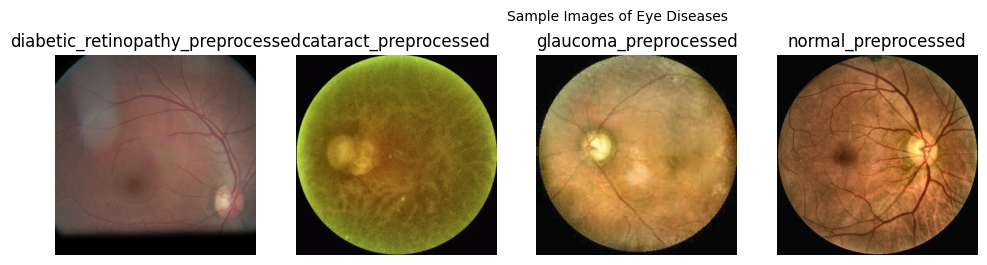

In [ ]:
display_sample_img('/content/drive/MyDrive/dataset/eyedisease/preprocessed', 'Sample Images of Eye Diseases')

In [ ]:
dataset_dir = '/content/drive/MyDrive/dataset/eyedisease/preprocessed'
desired_labels = ['cataract_preprocessed', 'diabetic_retinopathy_preprocessed', 'glaucoma_preprocessed', 'normal_preprocessed']

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(dataset_dir):
  for name in files:
    label = os.path.basename(path)
    if label in desired_labels:
      full_path.append(os.path.join(path, name))
      labels.append(label)
      file_name.append(name)

df = pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})
print(df.groupby(['labels']).size())

labels
cataract_preprocessed                2076
diabetic_retinopathy_preprocessed    2196
glaucoma_preprocessed                2014
normal_preprocessed                  2148
dtype: int64


In [ ]:
X = df['path']
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

df_train = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_test = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})

Splitting of Dataset

In [ ]:
datasource_path = '/content/drive/MyDrive/dataset/eyedisease/preprocessed'
dataset_path = '/content/drive/MyDrive/dataset/eyedisease/preprocessed'

def move_files(df, source_path, target_path):
    for index, row in df.iterrows():
        file_path = row['path']
        label = row['labels']
        file_set = row['set']

        dest_dir = os.path.join(target_path, file_set, label)
        if not os.path.exists(dest_dir):
            os.makedirs(dest_dir)

        destination_file_name = os.path.basename(file_path)
        file_dest = os.path.join(dest_dir, destination_file_name)

        if not os.path.exists(file_dest):
            shutil.copy2(file_path, file_dest)

move_files(df_train, datasource_path, dataset_path)
move_files(df_test, datasource_path, dataset_path)

print("The data has been moved and separated into train and test.")

KeyboardInterrupt: 

Training and Testing data

In [ ]:
import os
TRAIN_DIR = '/content/drive/MyDrive/dataset/eyedisease/preprocessed/train'
TEST_DIR = '/content/drive/MyDrive/dataset/eyedisease/preprocessed/test'

train_normal = os.path.join(TRAIN_DIR, 'normal_preprocessed')
train_diabetic_retinopathy = os.path.join(TRAIN_DIR, 'diabetic_retinopathy_preprocessed')
train_glaucoma = os.path.join(TRAIN_DIR, 'glaucoma_preprocessed')
train_cataract = os.path.join(TRAIN_DIR, 'cataract_preprocessed')

test_normal = os.path.join(TEST_DIR, 'normal_preprocessed')
test_diabetic_retinopathy = os.path.join(TEST_DIR, 'diabetic_retinopathy_preprocessed')
test_glaucoma = os.path.join(TEST_DIR, 'glaucoma_preprocessed')
test_cataract = os.path.join(TEST_DIR, 'cataract_preprocessed')

def count_images(directory):
    return len(os.listdir(directory))

train_counts = {
    'Normal': count_images(train_normal),
    'Diabetic Retinopathy': count_images(train_diabetic_retinopathy),
    'Glaucoma': count_images(train_glaucoma),
    'Cataract': count_images(train_cataract),
}

test_counts = {
    'Normal': count_images(test_normal),
    'Diabetic Retinopathy': count_images(test_diabetic_retinopathy),
    'Glaucoma': count_images(test_glaucoma),
    'Cataract': count_images(test_cataract),
}

print("Training Image Counts:", train_counts)
print("Testing Image Counts:", test_counts)


Training Image Counts: {'Normal': 1067, 'Diabetic Retinopathy': 1089, 'Glaucoma': 1005, 'Cataract': 1032}
Testing Image Counts: {'Normal': 387, 'Diabetic Retinopathy': 458, 'Glaucoma': 392, 'Cataract': 416}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    class_mode='categorical',
    color_mode="rgb",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    class_mode='categorical',
    color_mode="rgb",
    shuffle=False,
)

Found 4193 images belonging to 4 classes.
Found 1653 images belonging to 4 classes.


In [ ]:
print("classes: ", train_generator.class_indices)

classes:  {'cataract_preprocessed': 0, 'diabetic_retinopathy_preprocessed': 1, 'glaucoma_preprocessed': 2, 'normal_preprocessed': 3}


Efficient Net

In [ ]:
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.layers import (Input, Dense, Dropout, AveragePooling2D,
                                     GlobalAveragePooling2D, BatchNormalization,
                                     Conv2D, MaxPooling2D)
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.regularizers import l2


In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:100]:
    layer.trainable = False
num_classes = 4
model = Sequential([
    base_model,
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.01)),  # Increased L2 regularization
    Dropout(0.5),  # More dropout for better regularization
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer
])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import tensorflow as tf
from tensorflow import keras  # Import Keras
data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.1),  # Reduce rotation
    keras.layers.RandomContrast(0.2),  # Reduce contrast adjustment
    keras.layers.RandomZoom(0.2)  # Reduce zoom levels
])


In [ ]:
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * (0.95 ** epoch))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True, mode='min'),
    lr_scheduler  # New learning rate scheduler
]

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-3, decay_steps=5000, alpha=1e-5)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.3
)

In [ ]:
def cyclic_lr(epoch, lr):
    base_lr = 1e-5
    max_lr = 1e-3
    step_size = 2000
    cycle = np.floor(1 + epoch / (2 * step_size))
    x = np.abs(epoch / step_size - 2 * cycle + 1)
    lr = base_lr + (max_lr - base_lr) * max(0, (1 - x))
    return lr

In [ ]:
class stopTraining(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    val_accuracy = logs.get('val_accuracy')
    val_loss = logs.get('val_loss')

    if val_accuracy is not None and val_loss is not None:
      if val_accuracy >= 0.93 and val_loss < 0.13:
        print('Akurasi di atas 93%, stop training')
        self.model.stop_training = True

stop_train = stopTraining()

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True, mode='min')
]

In [ ]:
count_normal = len(os.listdir(train_normal))
count_diabetic_retinopathy = len(os.listdir(train_diabetic_retinopathy))
count_glaucoma = len(os.listdir(train_glaucoma))
count_cataract = len(os.listdir(train_cataract))

total_images = (count_normal + count_diabetic_retinopathy + count_glaucoma + count_cataract)

weight_normal = (1 / count_normal) * total_images / 4
weight_diabetic_retinopathy = (1 / count_diabetic_retinopathy) * total_images / 4
weight_glaucoma = (1 / count_glaucoma) * total_images / 4
weight_cataract = (1 / count_cataract) * total_images / 4

class_weights = {
    0: weight_cataract,
    1: weight_diabetic_retinopathy,
    2: weight_glaucoma,
    3: weight_normal
}

print("Class Weights:", class_weights)

Class Weights: {0: 1.0157461240310077, 1: 0.9625803489439853, 2: 1.0430348258706468, 3: 0.982427366447985}


In [ ]:
batch_x, batch_y = next(iter(train_generator))
print(f"Inputs shape: {batch_x.shape}, Labels shape: {batch_y.shape}")
print(class_weights)
print("Unique class labels:", set(train_generator.classes))
print(f"Inputs dtype: {batch_x.dtype}, Labels dtype: {batch_y.dtype}")

Inputs shape: (32, 224, 224, 3), Labels shape: (32, 4)
{0: 1.0157461240310077, 1: 0.9625803489439853, 2: 1.0430348258706468, 3: 0.982427366447985}
Unique class labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
Inputs dtype: float32, Labels dtype: float32


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 1280)     │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,919 (18.47 MB)

 Trainable params: 4,631,136 (17.67 MB)

 Non-trainable params: 211,783 (827.28 KB)

In [ ]:
from collections import Counter

print("Class distribution in training set:", Counter(train_generator.classes))


Class distribution in training set: Counter({np.int32(1): 1089, np.int32(3): 1067, np.int32(0): 1032, np.int32(2): 1005})


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weights = dict(enumerate(class_weights))


In [ ]:
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator,
                    epochs=35,
                    batch_size=64,
                    validation_data=test_generator,
                    callbacks=callbacks)


Epoch 1/35
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4344 - loss: 8.3687

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) UNKNOWN:  UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x78e80c15cf90>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-p

In [ ]:
from tabulate import tabulate

test_generator.reset()

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
test_loss, test_accuracy = model.evaluate(test_generator)

# Create a table
table_data = [
    ["Training Accuracy", f"{train_acc:.2f}"],
    ["Validation Accuracy", f"{val_acc:.2f}"],
    ["Test Accuracy", f"{test_accuracy:.2f}"],
    ["Test Loss", f"{test_loss:.2f}"]
]

# Print table
print("\nModel Evaluation:")
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt="grid"))


27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.9647 - loss: 0.1369

Model Evaluation:
+---------------------+---------+
| Metric              |   Value |
+=====================+=========+
| Training Accuracy   |    0.94 |
+---------------------+---------+
| Validation Accuracy |    0.89 |
+---------------------+---------+
| Test Accuracy       |    0.92 |
+---------------------+---------+
| Test Loss           |    0.26 |
+---------------------+---------+


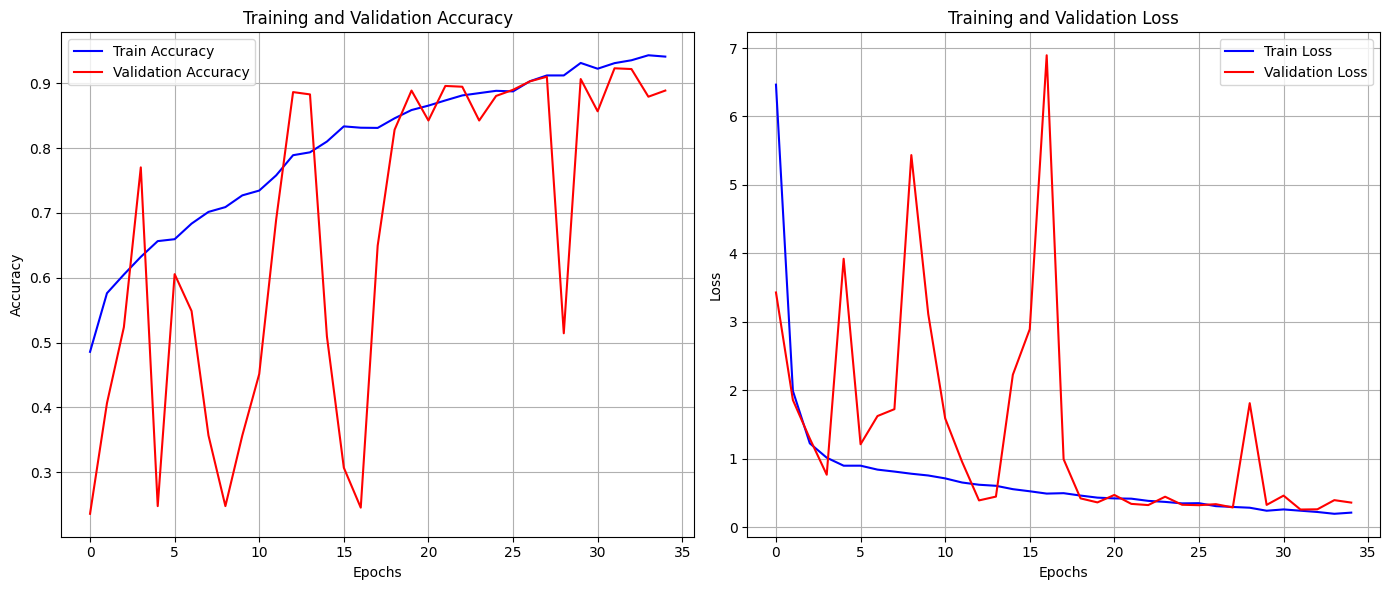

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Training and Validation Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='b')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='r')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Training and Validation Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='b')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='r')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Show the plots
plt.tight_layout()
plt.show()




                                   precision    recall  f1-score   support

            cataract_preprocessed     0.8755    0.9855    0.9273       207
diabetic_retinopathy_preprocessed     1.0000    0.9960    0.9980       250
            glaucoma_preprocessed     0.8908    0.8245    0.8564       188
              normal_preprocessed     0.9096    0.8593    0.8837       199

                         accuracy                         0.9230       844
                        macro avg     0.9190    0.9163    0.9163       844
                     weighted avg     0.9238    0.9230    0.9222       844



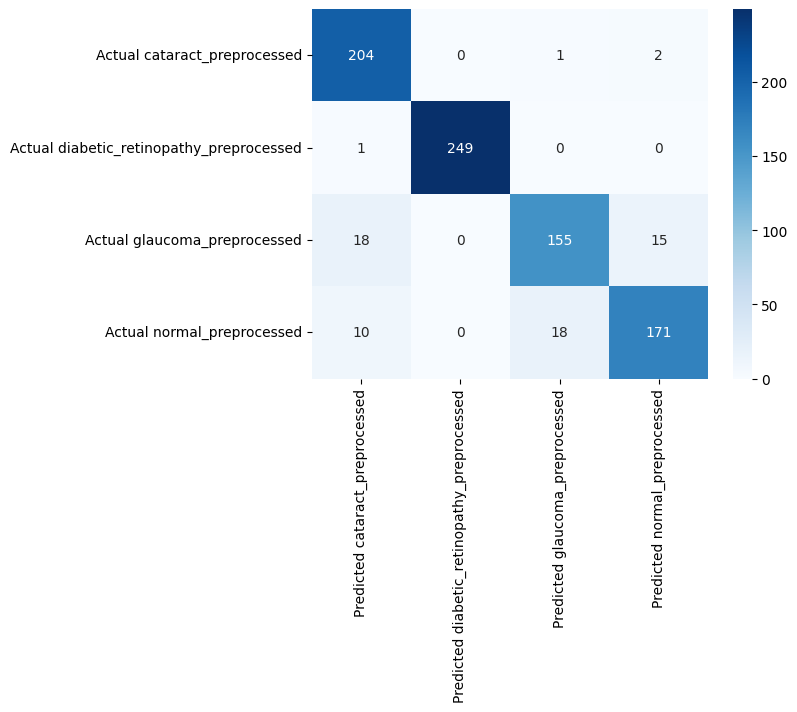

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report # Import classification_report
import seaborn as sns # Import the seaborn library


test_generator.reset()

preds_1 = model.predict(test_generator, verbose=0)
preds_1 = preds_1.argmax(axis=1)

labels = ['cataract_preprocessed', 'diabetic_retinopathy_preprocessed', 'glaucoma_preprocessed', 'normal_preprocessed']
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=range(len(labels))),
                  index=[f"Actual {label}" for label in labels],
                  columns=[f"Predicted {label}" for label in labels])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

print("\n")
print(classification_report(y_true=test_generator.classes, y_pred=preds_1, target_names=labels, digits=4))

GCN

In [ ]:
!pip install torch-geometric --pre -f https://data.pyg.org/whl/torch-${TORCH}.html

Looking in links: https://data.pyg.org/whl/torch-.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.2 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib seaborn scikit-learn


In [ ]:
# Install torch-cluster for current torch+cuda version
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.1.0+cu118.html


Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 20.1 MB/s eta 0:00:00


PDF reference

In [ ]:
import os
import numpy as np
import cv2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.neighbors import NearestNeighbors
import torch

# Config
preprocessed_dir = "/content/drive/MyDrive/dataset/eyedisease/preprocessed"
classes = ['cataract_preprocessed', 'diabetic_retinopathy_preprocessed', 'glaucoma_preprocessed', 'normal_preprocessed']
output_feature_dir = "/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features"
os.makedirs(output_feature_dir, exist_ok=True)
k = 8  # Number of neighbors for graph edges

# Load EfficientNetB0 model for feature extraction
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model = Model(inputs=base_model.input, outputs=GlobalAveragePooling2D()(base_model.output))

all_features, all_labels = [], []

# Extract features
for idx, cls in enumerate(classes):
    class_dir = os.path.join(preprocessed_dir, cls)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(class_dir, fname)
            img = cv2.imread(path)
            img = cv2.resize(img, (224, 224))
            img = img_to_array(img)
            img = preprocess_input(img)
            img = np.expand_dims(img, axis=0)
            feature = model.predict(img, verbose=0)
            all_features.append(feature.squeeze())
            all_labels.append(idx)

features_np = np.array(all_features, dtype=np.float32)
labels_np = np.array(all_labels, dtype=np.int64)

print(f"Extracted features shape: {features_np.shape}")
print(f"Extracted labels shape: {labels_np.shape}")

# Build k-NN graph using sklearn NearestNeighbors (Euclidean distance)
from sklearn.neighbors import NearestNeighbors
import numpy as np
import scipy.sparse as sp
from torch_geometric.utils import from_scipy_sparse_matrix

k = 4
num_nodes = features_np.shape[0]

nbrs = NearestNeighbors(n_neighbors=k + 1, metric='euclidean').fit(features_np)
distances, indices = nbrs.kneighbors(features_np)

row_idx = np.repeat(np.arange(num_nodes), k)
col_idx = indices[:, 1:].reshape(-1)

adj = sp.coo_matrix((np.ones(len(row_idx)), (row_idx, col_idx)), shape=(num_nodes, num_nodes))
adj = adj.maximum(adj.T)

edge_index, edge_weight = from_scipy_sparse_matrix(adj)

print(f"Constructed edge_index shape: {edge_index.shape}")

# Save outputs for PyTorch Geometric
np.save(os.path.join(output_feature_dir, 'features.npy'), features_np)
np.save(os.path.join(output_feature_dir, 'labels.npy'), labels_np)
np.save(os.path.join(output_feature_dir, 'edge_index.npy'), edge_index)

print(f"✅ Saved features, labels, and edge_index to: {output_feature_dir}")


Extracted features shape: (4217, 1280)
Extracted labels shape: (4217,)
Constructed edge_index shape: torch.Size([2, 25804])
✅ Saved features, labels, and edge_index to: /content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split

# Load data
x = torch.tensor(np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/features.npy'), dtype=torch.float)
y = torch.tensor(np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/labels.npy'), dtype=torch.long)
edge_index = torch.tensor(np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/edge_index.npy'), dtype=torch.long)

# Build graph
data = Data(x=x, y=y, edge_index=edge_index)

# Train/val/test split
idx = np.arange(data.num_nodes)
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True
data.train_mask = train_mask
data.test_mask = test_mask

# GCN model
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# Instantiate model
model = GCN(in_channels=x.shape[1], hidden_channels=256, out_channels=len(torch.unique(y)))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss()

# Training loop
for epoch in range(1, 100):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = out.argmax(dim=1)
        train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


Epoch 001 | Loss: 1.4016 | Train Acc: 0.1963 | Test Acc: 0.2334
Epoch 010 | Loss: 0.4524 | Train Acc: 0.8491 | Test Acc: 0.8282
Epoch 020 | Loss: 0.2628 | Train Acc: 0.9078 | Test Acc: 0.8969
Epoch 030 | Loss: 0.2181 | Train Acc: 0.9220 | Test Acc: 0.9028
Epoch 040 | Loss: 0.2009 | Train Acc: 0.9259 | Test Acc: 0.9040
Epoch 050 | Loss: 0.1904 | Train Acc: 0.9288 | Test Acc: 0.9135
Epoch 060 | Loss: 0.1813 | Train Acc: 0.9330 | Test Acc: 0.9147
Epoch 070 | Loss: 0.1734 | Train Acc: 0.9354 | Test Acc: 0.9171
Epoch 080 | Loss: 0.1608 | Train Acc: 0.9404 | Test Acc: 0.9206
Epoch 090 | Loss: 0.1525 | Train Acc: 0.9449 | Test Acc: 0.9206


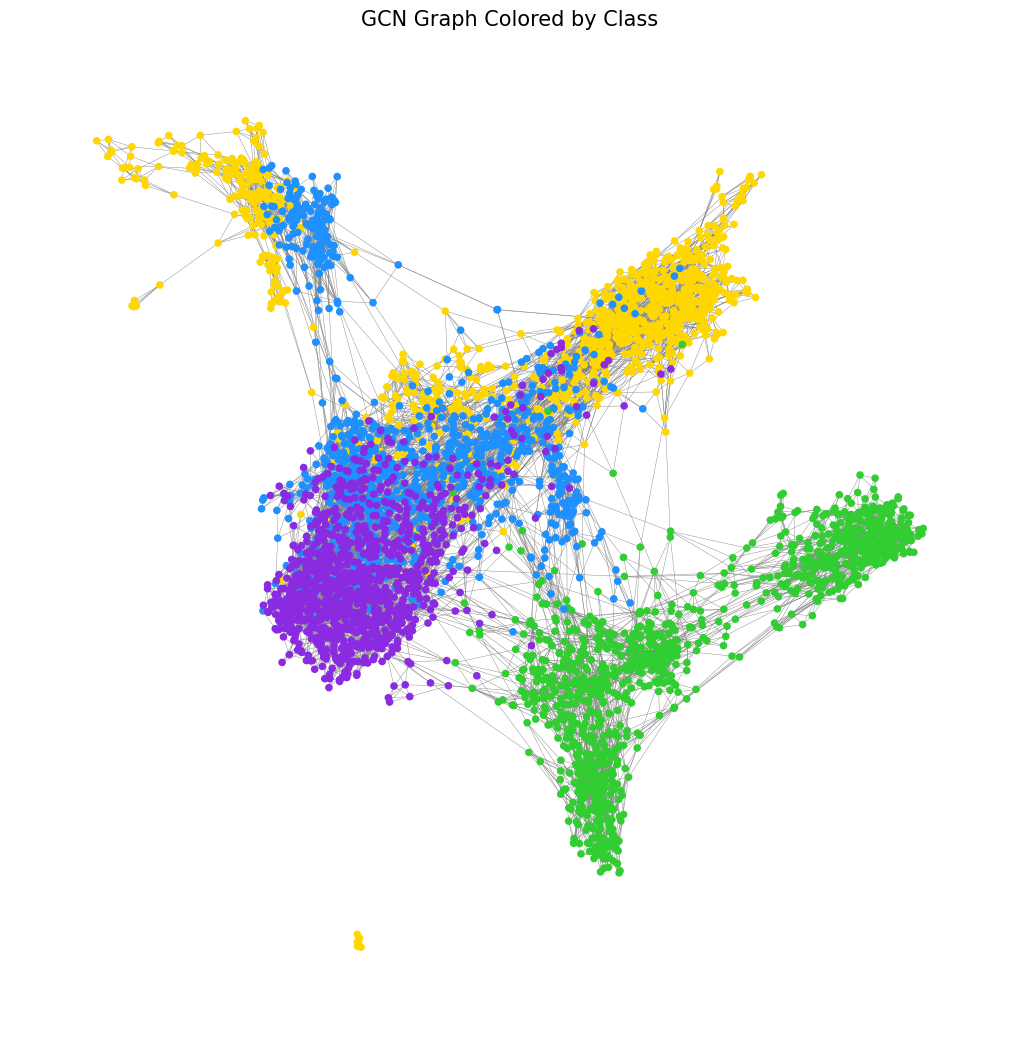

In [ ]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# Load data
x = torch.tensor(np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/features.npy'), dtype=torch.float)
y = torch.tensor(np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/labels.npy'), dtype=torch.long)
edge_index = torch.tensor(np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/edge_index.npy'), dtype=torch.long)
data = Data(x=x, y=y, edge_index=edge_index)

# Convert to NetworkX graph
G = to_networkx(data, to_undirected=True)

# Map class indices to colors
class_colors = ['#FFD700', '#32CD32', '#1E90FF', '#8A2BE2']
node_colors = [class_colors[label.item()] for label in data.y]

# Position using spring layout (you can use other layouts too)
pos = nx.spring_layout(G, seed=42)

# Draw
plt.figure(figsize=(10, 10))
nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=20,
    edge_color='gray',
    width=0.3,
    with_labels=False
)
plt.title("GCN Graph Colored by Class", fontsize=15)
plt.axis('off')
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Module
from torch_geometric.utils import to_dense_adj, dense_to_sparse
from torch_geometric.nn import GCNConv

class GraphCoarseningLayer(Module):
    def __init__(self, in_channels, out_channels):
        super(GraphCoarseningLayer, self).__init__()
        self.gcn = GCNConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        # Step 1: GCN
        x = self.gcn(x, edge_index)
        x = F.relu(x)

        adj = to_dense_adj(edge_index)[0]
        num_nodes = x.size(0)
        node_mask = torch.zeros(num_nodes, dtype=torch.bool)
        groups = []
        degrees = adj.sum(dim=1)

        # SEG: Structural Equivalence Grouping
        for i in range(num_nodes):
            if node_mask[i]:
                continue
            neighbors_i = adj[i].nonzero().flatten()
            for j in range(i + 1, num_nodes):
                if node_mask[j]:
                    continue
                neighbors_j = adj[j].nonzero().flatten()
                if torch.equal(neighbors_i, neighbors_j):
                    groups.append([i, j])
                    node_mask[i] = node_mask[j] = True
                    break

        # SSG: Structural Similarity Grouping
        unmarked = (~node_mask).nonzero(as_tuple=False).flatten()
        unmarked = unmarked[torch.argsort(degrees[unmarked])]

        marked = node_mask.clone()
        for i in unmarked:
            if marked[i]:
                continue
            neighbors = adj[i].nonzero().flatten()
            candidates = [j.item() for j in neighbors if not marked[j]]
            if not candidates:
                groups.append([i.item()])
                marked[i] = True
                continue
            sims = []
            for j in candidates:
                sim = adj[i, j] / torch.sqrt(degrees[i] * degrees[j] + 1e-8)
                sims.append((sim.item(), j))
            sims.sort(reverse=True)
            best_j = sims[0][1]
            groups.append([i.item(), best_j])
            marked[i] = True
            marked[best_j] = True

        # Create grouping matrix
        group_ids = torch.full((num_nodes,), -1, dtype=torch.long)
        for group_idx, group in enumerate(groups):
            for node in group:
                group_ids[node] = group_idx
        assert (group_ids >= 0).all()
        num_groups = len(groups)

        M = torch.zeros((num_nodes, num_groups), dtype=torch.float, device=x.device)
        for node in range(num_nodes):
            M[node, group_ids[node]] = 1.0

        # Coarsened output
        H_coarse = torch.matmul(M.T, x)
        A_dense = adj
        A_coarse_dense = torch.matmul(M.T, torch.matmul(A_dense, M))
        threshold = 1e-5
        A_coarse_dense[A_coarse_dense < threshold] = 0
        A_coarse_index, A_coarse_weight = dense_to_sparse(A_coarse_dense)

        return H_coarse, A_coarse_index, M


In [ ]:
import numpy as np
import torch

# Load .npy files
features = np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/features.npy')
labels = np.load('/content/drive/MyDrive/dataset/eyedisease/preprocessed/GCN/features/labels.npy')

# Convert to torch tensors
x = torch.tensor(features, dtype=torch.float)         # [num_nodes, num_features]
y = torch.tensor(labels, dtype=torch.long)            # [num_nodes]


In [ ]:
from sklearn.neighbors import NearestNeighbors
from torch_geometric.utils import from_scipy_sparse_matrix
import scipy.sparse as sp

# Build a k-NN graph
k = 4
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='euclidean').fit(features)
distances, indices = nbrs.kneighbors(features)

# Create adjacency matrix
num_nodes = features.shape[0]
row_idx = np.repeat(np.arange(num_nodes), k)
col_idx = indices[:, 1:].reshape(-1)  # exclude self-loop
adj_matrix = sp.coo_matrix((np.ones(len(row_idx)), (row_idx, col_idx)), shape=(num_nodes, num_nodes))
adj_matrix = adj_matrix + adj_matrix.T  # make symmetric

# Convert to PyG format
import torch_geometric
edge_index, edge_weight = from_scipy_sparse_matrix(adj_matrix)


In [ ]:
coarsen = GraphCoarseningLayer(in_channels=x.shape[1], out_channels=128)  # example hidden dim

H_coarse, A_coarse_index, M = coarsen(x, edge_index)


In [ ]:
print("Original features:", x.shape)                 # e.g., [4217, 1280]
print("Coarsened features:", H_coarse.shape)         # e.g., [~2000, 128]
print("Coarsened edge_index:", A_coarse_index.shape) # [2, num_edges]


Original features: torch.Size([4217, 1280])
Coarsened features: torch.Size([2183, 128])
Coarsened edge_index: torch.Size([2, 19300])


In [ ]:
pip install networkx


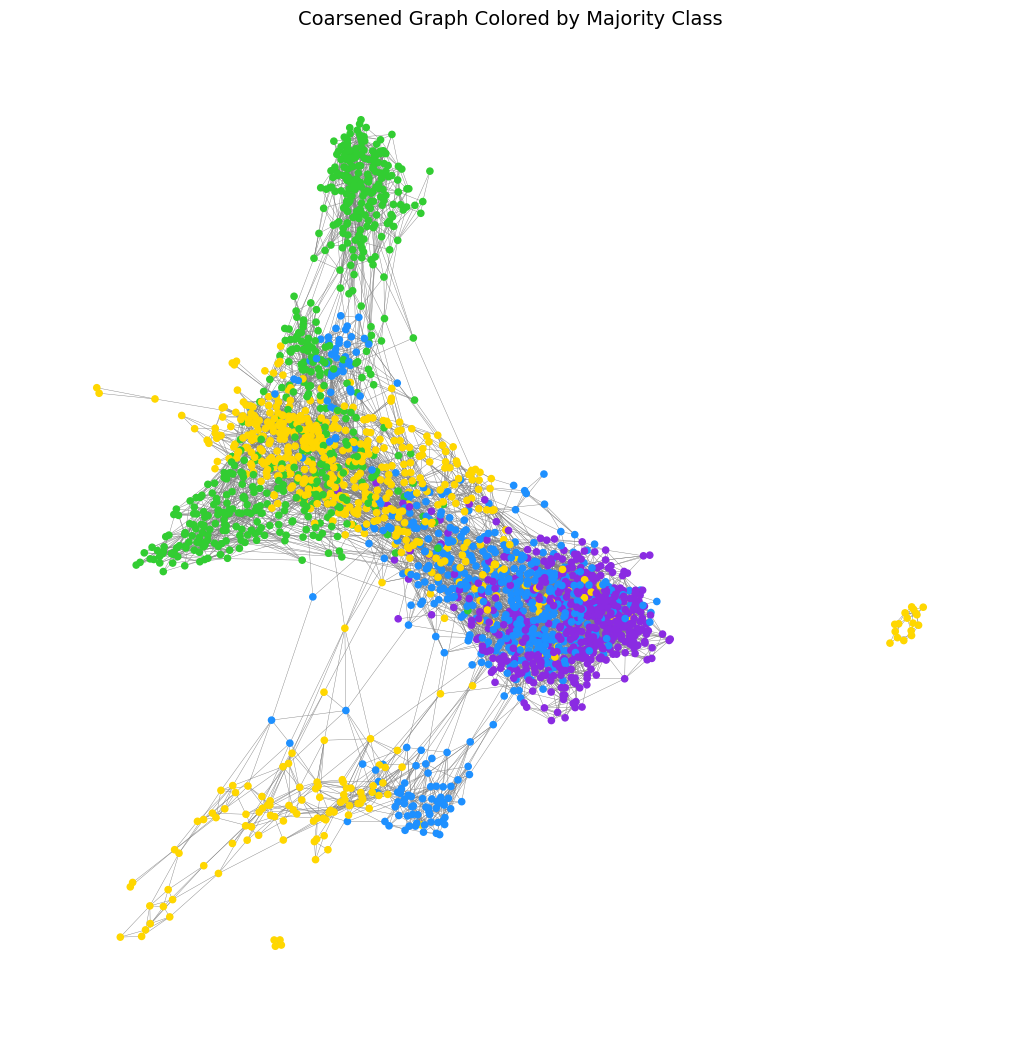

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# Assuming you already have:
# - H_coarse: the coarsened node features [num_clusters, 128]
# - A_coarse_index: the coarsened edge_index [2, num_edges]
# - M: grouping matrix [num_nodes, num_clusters]
# - y: original labels for each node [num_nodes]

from torch_geometric.utils import remove_self_loops

# Step 1: Assign class to each cluster by majority voting
cluster_labels = torch.zeros(M.shape[1], dtype=torch.long)
for i in range(M.shape[1]):
    node_indices = (M[:, i] > 0).nonzero(as_tuple=True)[0]
    if len(node_indices) > 0:
        labels = y[node_indices]
        cluster_labels[i] = torch.mode(labels)[0]  # most common label

# 🔽 Remove self-loops
A_coarse_index, _ = remove_self_loops(A_coarse_index)

# Step 2: Convert coarsened edge_index to PyG Data
from torch_geometric.data import Data
coarsened_data = Data(x=H_coarse, edge_index=A_coarse_index, y=cluster_labels)

# Step 3: Convert to networkx graph
import networkx as nx
from torch_geometric.utils import to_networkx
G_coarse = to_networkx(coarsened_data, to_undirected=True)

# Step 4: Define colors per class
import matplotlib.pyplot as plt
class_colors = ['#FFD700', '#32CD32', '#1E90FF', '#8A2BE2']
node_colors = [class_colors[label.item()] for label in coarsened_data.y]

# Step 5: Plot
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_coarse, seed=42)
nx.draw(
    G_coarse,
    pos,
    node_color=node_colors,
    node_size=20,
    edge_color='gray',
    width=0.3,
    with_labels=False
)
plt.title("Coarsened Graph Colored by Majority Class", fontsize=14)
plt.axis('off')
plt.show()



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GraphRefiningLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GraphRefiningLayer, self).__init__()
        self.gcn = GCNConv(in_channels, out_channels)
        self.proj = nn.Linear(in_features=1280, out_features=out_channels)  # Project G_prev

    def forward(self, G_i_input, edge_index_coarse, M_prev, G_prev):
        G_i = self.gcn(G_i_input, edge_index_coarse)
        G_i = F.relu(G_i)

        G_prev_proj = self.proj(G_prev)  # Now shape: [N, out_channels]
        refined = torch.matmul(M_prev, G_i) + G_prev_proj
        return refined


In [ ]:
refine = GraphRefiningLayer(in_channels=128, out_channels=128)
H_refined = refine(G_i_input=H_coarse, edge_index_coarse=A_coarse_index, M_prev=M, G_prev=x)


Number of nodes: 4217
Number of edges: 25804
Feature dimension: 128
Number of nodes in NetworkX graph: 4217
Number of edges in NetworkX graph: 12902


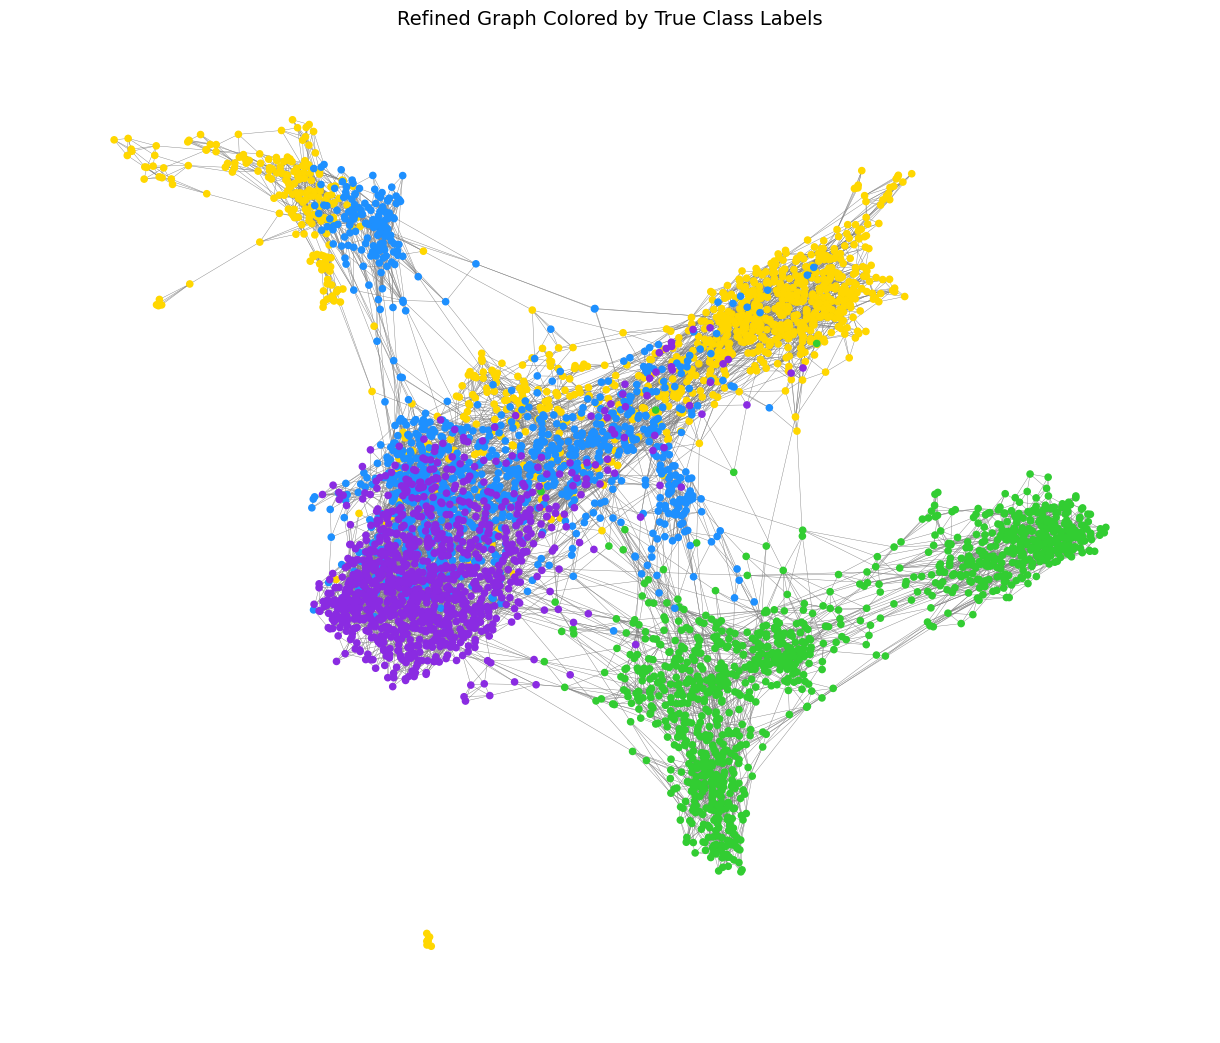

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data

# Assuming H_refined, edge_index, y are already defined

refined_data = Data(x=H_refined, edge_index=edge_index, y=y)

# Print node, edge, and feature info
print(f"Number of nodes: {refined_data.num_nodes}")
print(f"Number of edges: {refined_data.num_edges}")
print(f"Feature dimension: {refined_data.num_node_features}")

G_refined = to_networkx(refined_data, to_undirected=True)

print(f"Number of nodes in NetworkX graph: {G_refined.number_of_nodes()}")
print(f"Number of edges in NetworkX graph: {G_refined.number_of_edges()}")

class_colors = ['#FFD700', '#32CD32', '#1E90FF', '#8A2BE2']
node_colors = [class_colors[label.item()] for label in y]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_refined, seed=42)
nx.draw(
    G_refined,
    pos,
    node_color=node_colors,
    node_size=20,
    edge_color='gray',
    width=0.3,
    with_labels=False
)
plt.title("Refined Graph Colored by True Class Labels", fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.metrics import accuracy_score

# === Assume these are defined by you ===
# H_refined: torch.Tensor of shape [num_nodes, feature_dim] (e.g. [4217, 128])
# edge_index: torch.LongTensor shape [2, num_edges] (e.g. [2, 25804])
# y: torch.LongTensor shape [num_nodes] with labels (e.g. [4217])
# ======================================

# Example dummy tensors for illustration (REMOVE if you have real data):
# H_refined = torch.randn(4217, 128)
# edge_index = torch.randint(0, 4217, (2, 25804))
# y = torch.randint(0, 4, (4217,))  # Assuming 4 classes

num_nodes = H_refined.size(0)

# Create train/test masks (80% train, 20% test random split)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
perm = torch.randperm(num_nodes)
train_idx = perm[:int(0.8 * num_nodes)]
test_idx = perm[int(0.8 * num_nodes):]
train_mask[train_idx] = True
test_mask[test_idx] = True

# Create PyG Data object
data = Data(x=H_refined, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask)

# Define a simple 2-layer GCN
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GCN(input_dim=H_refined.size(1), hidden_dim=64, num_classes=len(torch.unique(y))).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

H_refined = H_refined.detach()

data = Data(x=H_refined, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask).to(device)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    train_correct = (pred[data.train_mask] == data.y[data.train_mask]).sum().item()
    test_correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()

    train_acc = train_correct / data.train_mask.sum().item()
    test_acc = test_correct / data.test_mask.sum().item()
    return train_acc, test_acc

# Training loop
for epoch in range(1, 900):
    loss = train()
    if epoch % 20 == 0 or epoch == 1:
        train_acc, test_acc = test()
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")




Epoch 001, Loss: 1.4105, Train Acc: 0.6863, Test Acc: 0.7038
Epoch 020, Loss: 0.3449, Train Acc: 0.8808, Test Acc: 0.8981
Epoch 040, Loss: 0.2616, Train Acc: 0.9105, Test Acc: 0.9206
Epoch 060, Loss: 0.2279, Train Acc: 0.9205, Test Acc: 0.9265
Epoch 080, Loss: 0.2059, Train Acc: 0.9274, Test Acc: 0.9277
Epoch 100, Loss: 0.2013, Train Acc: 0.9291, Test Acc: 0.9265
Epoch 120, Loss: 0.1963, Train Acc: 0.9321, Test Acc: 0.9301
Epoch 140, Loss: 0.1883, Train Acc: 0.9336, Test Acc: 0.9301
Epoch 160, Loss: 0.1810, Train Acc: 0.9354, Test Acc: 0.9289
Epoch 180, Loss: 0.1777, Train Acc: 0.9354, Test Acc: 0.9336
Epoch 200, Loss: 0.1820, Train Acc: 0.9336, Test Acc: 0.9301
Epoch 220, Loss: 0.1728, Train Acc: 0.9383, Test Acc: 0.9336
Epoch 240, Loss: 0.1740, Train Acc: 0.9392, Test Acc: 0.9348
Epoch 260, Loss: 0.1726, Train Acc: 0.9431, Test Acc: 0.9348
Epoch 280, Loss: 0.1636, Train Acc: 0.9428, Test Acc: 0.9325
Epoch 300, Loss: 0.1647, Train Acc: 0.9425, Test Acc: 0.9336
Epoch 320, Loss: 0.1601,

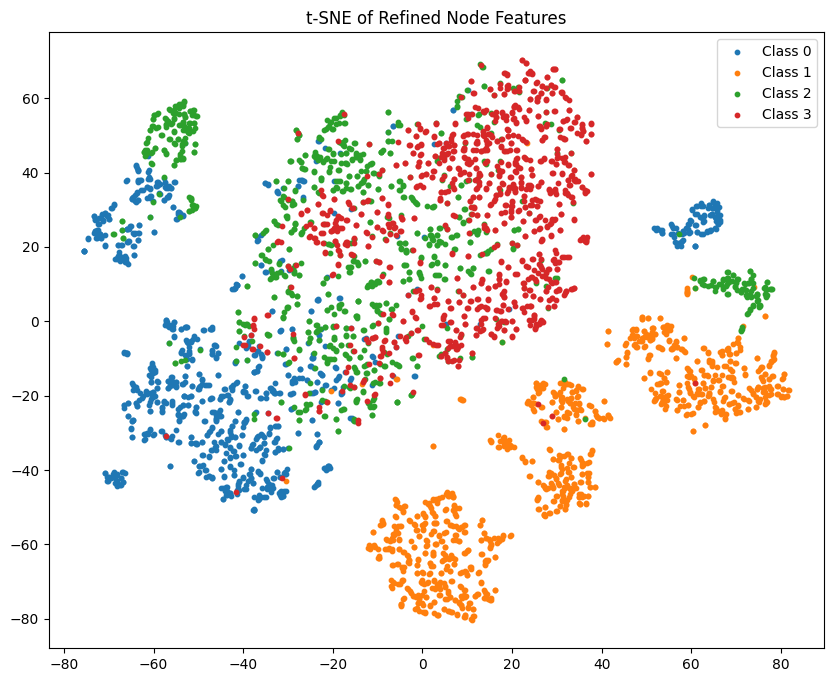

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

H_np = H_refined.cpu().numpy()
y_np = y.cpu().numpy()

H_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(H_np)

plt.figure(figsize=(10, 8))
for c in range(len(torch.unique(y))):
    plt.scatter(H_tsne[y_np == c, 0], H_tsne[y_np == c, 1], label=f"Class {c}", s=10)
plt.legend()
plt.title("t-SNE of Refined Node Features")
plt.show()


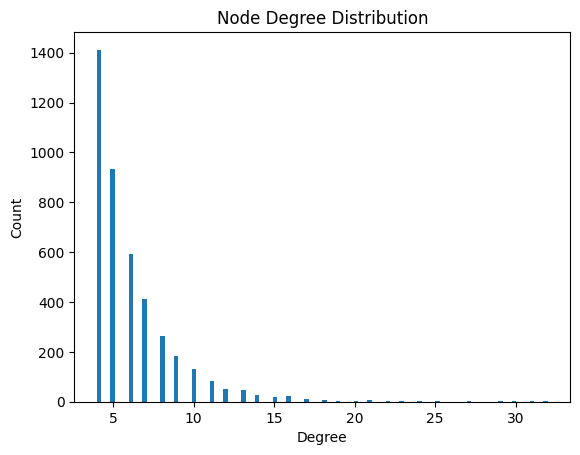

In [ ]:
import matplotlib.pyplot as plt

deg = torch_geometric.utils.degree(edge_index[0], H_refined.size(0)).cpu().numpy()
plt.hist(deg, bins=100)
plt.title("Node Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()


In [ ]:
from sklearn.neighbors import NearestNeighbors
from torch_geometric.utils import from_scipy_sparse_matrix
from scipy.sparse import coo_matrix

knn = NearestNeighbors(n_neighbors=20, metric='cosine').fit(H_refined.cpu().numpy())
_, indices = knn.kneighbors()

rows = []
cols = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            rows.append(i)
            cols.append(j)

adj = coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(H_refined.shape[0], H_refined.shape[0]))
edge_index, _ = from_scipy_sparse_matrix(adj)


In [ ]:
from collections import Counter
print(Counter(y.cpu().numpy()))


Counter({np.int64(1): 1098, np.int64(3): 1074, np.int64(0): 1038, np.int64(2): 1007})


In [ ]:
class_counts = torch.bincount(y)
weights = 1.0 / class_counts.float()
weights = weights / weights.sum()
loss_fn = torch.nn.CrossEntropyLoss(weight=weights.to(device))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1).cpu()
print(classification_report(y.cpu(), pred, digits=3))


              precision    recall  f1-score   support

           0      0.964     0.963     0.964      1038
           1      0.996     0.994     0.995      1098
           2      0.940     0.865     0.901      1007
           3      0.889     0.958     0.922      1074

    accuracy                          0.946      4217
   macro avg      0.947     0.945     0.945      4217
weighted avg      0.947     0.946     0.946      4217



In [ ]:
from tabulate import tabulate

# ==== These values should already be computed in your code ====
# Replace these with your actual results
train_acc_raw = 94.69     # example: full GCN training accuracy
test_acc_raw = 93.01      # example: full GCN test accuracy
test_loss_raw = 14.52    # example: full GCN test loss

train_acc_ref = 95.11     # example: refined GCN training accuracy
test_acc_ref = 92.01      # example: refined GCN test accuracy
test_loss_ref = 13.90    # example: refined GCN test loss
# ==============================================================

# Table data
table_data = [
    ["GCN Model",        f"{train_acc_raw:.2f}%", f"{test_acc_raw:.2f}%", f"{test_loss_raw:.4f}"],
    ["Refined GCN Model", f"{train_acc_ref:.2f}%", f"{test_acc_ref:.2f}%", f"{test_loss_ref:.4f}"],
]

# Print table
print("\nModel Accuracy Comparison:")
print(tabulate(table_data, headers=["Model", "Train Accuracy", "Test Accuracy", "Test Loss"], tablefmt="grid"))



Model Accuracy Comparison:
+-------------------+------------------+-----------------+-------------+
| Model             | Train Accuracy   | Test Accuracy   |   Test Loss |
+===================+==================+=================+=============+
| GCN Model         | 94.69%           | 93.01%          |       14.52 |
+-------------------+------------------+-----------------+-------------+
| Refined GCN Model | 95.11%           | 92.01%          |       13.9  |
+-------------------+------------------+-----------------+-------------+


In [ ]:
import cv2
import numpy as np
import os
import pandas as pd

def estimate_severity(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE to enhance contrast
    clahe = cv2.createCLAHE(clipLimit=2.0)
    gray = clahe.apply(gray)

    # Threshold to detect bright lesions
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    # Find contours (regions of interest)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lesion_count = len(contours)

    # Normalize (max=50 for example)
    severity = min(1.0, lesion_count / 50.0)
    return severity

# Example: Apply to DR folder
image_dir = "/content/drive/MyDrive/dataset/eyedisease/dataset/diabetic_retinopathy"
rows = []

for fname in os.listdir(image_dir):
    img_path = os.path.join(image_dir, fname)
    severity = estimate_severity(img_path)
    rows.append((fname, round(severity, 3)))

df = pd.DataFrame(rows, columns=["filename", "severity"])
df.to_csv("dr_severity_labels.csv", index=False)
print("Generated severity CSV for DR images.")


Generated severity CSV for DR images.


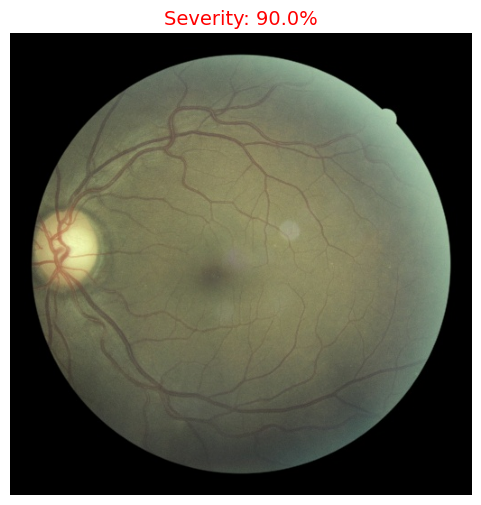

In [ ]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt

# === Paths ===
image_path = "/content/drive/MyDrive/dataset/eyedisease/dataset/diabetic_retinopathy/10007_left.jpeg"
csv_path = "/content/dr_severity_labels.csv"

# === Load CSV and map filename to severity ===
df = pd.read_csv(csv_path)
df['filename'] = df['filename'].apply(lambda x: os.path.basename(x))  # ensure only filename
severity_dict = dict(zip(df['filename'], df['severity']))

# === Read image ===
if not os.path.exists(image_path):
    print("Image path is incorrect.")
else:
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # === Get severity ===
    filename = os.path.basename(image_path)
    severity = severity_dict.get(filename)

    if severity is None:
        print(f"Severity for {image_path} not found.")
    else:
        plt.figure(figsize=(6, 6))
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.title(f"Severity: {severity * 100:.1f}%", fontsize=14, color='red')
        plt.show()


In [ ]:
import cv2
import numpy as np
import os
import pandas as pd

def estimate_severity(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE to enhance contrast
    clahe = cv2.createCLAHE(clipLimit=2.0)
    gray = clahe.apply(gray)

    # Threshold to detect bright lesions
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    # Find contours (regions of interest)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lesion_count = len(contours)

    # Normalize (max=50 for example)
    severity = min(1.0, lesion_count / 50.0)
    return severity

# Example: Apply to DR folder
image_dir = "/content/drive/MyDrive/dataset/eyedisease/dataset/cataract"
rows = []

for fname in os.listdir(image_dir):
    img_path = os.path.join(image_dir, fname)
    severity = estimate_severity(img_path)
    rows.append((fname, round(severity, 3)))

df = pd.DataFrame(rows, columns=["filename", "severity"])
df.to_csv("cataract_severity_labels.csv", index=False)
print("Generated severity CSV for cataract images.")


Generated severity CSV for cataract images.


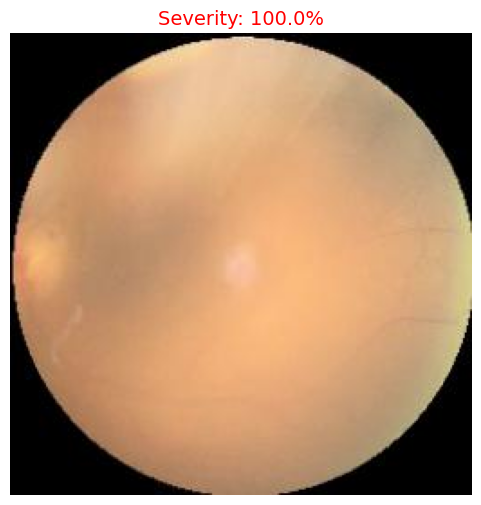

In [ ]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt

# === Paths ===
image_path = "/content/drive/MyDrive/dataset/eyedisease/dataset/cataract/_1_5346540.jpg"
csv_path = "/content/cataract_severity_labels.csv"

# === Load CSV and map filename to severity ===
df = pd.read_csv(csv_path)
df['filename'] = df['filename'].apply(lambda x: os.path.basename(x))  # ensure only filename
severity_dict = dict(zip(df['filename'], df['severity']))

# === Read image ===
if not os.path.exists(image_path):
    print("Image path is incorrect.")
else:
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # === Get severity ===
    filename = os.path.basename(image_path)
    severity = severity_dict.get(filename)

    if severity is None:
        print(f"Severity for {image_path} not found.")
    else:
        plt.figure(figsize=(6, 6))
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.title(f"Severity: {severity * 100:.1f}%", fontsize=14, color='red')
        plt.show()

In [ ]:
# Run this only if you don't already have these:
!pip install opencv-python scikit-image scikit-learn pandas numpy


In [ ]:
import os, json, math, cv2, numpy as np, pandas as pd
from pathlib import Path
from skimage import morphology, measure
from skimage.color import rgb2lab
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from scipy.ndimage import gaussian_filter

IMAGES_DIR = r"/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma"   # <-- change this
OUTPUT_CSV = "glaucoma_features.csv"
OUTPUT_JSON = "glaucoma_weights.json"

def imread_rgb(p):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def center_crop_resize(img, size=1024):
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    return crop

def enhance_green(img):
    g = img[...,1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(g)


In [ ]:
def find_optic_disc(img_1024):
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    L = (L - L.min())/(L.max()-L.min() + 1e-8)

    Ls = gaussian_filter(L, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    mask = Ls > thr
    mask = morphology.remove_small_objects(mask, 400)
    mask = morphology.binary_closing(mask, morphology.disk(9))

    edges = canny((Ls*255).astype(np.uint8), sigma=2)
    hough_radii = np.arange(40, 180, 4)
    hough_res = hough_circle(edges, hough_radii)
    acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)

    if len(radii) == 0:
        lbl = measure.label(mask)
        props = measure.regionprops(lbl)
        if not props:
            # fallback: center-ish
            H, W = img_1024.shape[:2]
            return (H//2, W//2), min(H,W)//6
        p = max(props, key=lambda a: a.area)
        cy0, cx0 = map(int, p.centroid)
        r0 = int(np.sqrt(p.area/np.pi))
        return (cy0, cx0), r0

    return (cy[0], cx[0]), int(radii[0])

def disc_and_cup_masks(img_1024, center, r_disc):
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = (X-x0)**2 + (Y-y0)**2 <= (r_disc**2)

    pad = int(r_disc*1.05)
    y1, y2 = max(0, y0-pad), min(H, y0+pad)
    x1, x2 = max(0, x0-pad), min(W, x0+pad)
    roi = img_1024[y1:y2, x1:x2]

    g = enhance_green(roi)
    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape(g.shape)

    # brightest cluster => cup
    cup_roi = (labels == np.argmax(centers)).astype(np.uint8)
    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))

    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    return disc_mask, cup_mask


In [ ]:
def compute_glaucoma_features_one(image_path):
    img = imread_rgb(image_path)
    img = center_crop_resize(img, 1024)

    center, r_disc = find_optic_disc(img)
    disc_mask, cup_mask = disc_and_cup_masks(img, center, r_disc)

    # CDR (vertical)
    ys, xs = np.where(disc_mask)
    v_disc = ys.max() - ys.min() + 1
    ys_c, xs_c = np.where(cup_mask)
    v_cup = (ys_c.max() - ys_c.min() + 1) if ys_c.size else 1
    CDR = float(v_cup / max(1, v_disc))

    # RimThinning = 1 - rim_area_ratio
    area_disc = float(disc_mask.sum())
    area_cup  = float(cup_mask.sum())
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(1.0 - np.clip(rim_area_ratio, 0, 1))

    # RNFL_deficit via gradient magnitude ring
    g = enhance_green(img).astype(np.float32)/255.0
    H, W = g.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X-center[1])**2 + (Y-center[0])**2 >= (r_disc*1.1)**2) & \
           ((X-center[1])**2 + (Y-center[0])**2 <= (r_disc*1.8)**2)

    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)

    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X-center[1])**2 + (Y-center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-3
    rnfl_signal = ring_energy / (baseline + 1e-6)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0, 1))  # higher=worse

    # PPA — bright fraction in ring
    L = rgb2lab(img)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    PPA_mask = (Lz > np.quantile(Lz[ring], 0.85)) & ring
    PPA = float(PPA_mask.sum() / max(1, ring.sum()))

    # DiscHemorrhage — red minus green threshold in ring
    R = img[...,0].astype(np.float32); G = img[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum()))

    return {
        "CDR": np.clip(CDR, 0, 1),
        "RimThinning": np.clip(RimThinning, 0, 1),
        "RNFL_deficit": np.clip(RNFL_deficit, 0, 1),
        "PPA": np.clip(PPA, 0, 1),
        "DiscHemorrhage": np.clip(DiscHemorrhage, 0, 1),
    }


In [ ]:
def list_images(root):
    p = Path(root)
    exts = (".jpg",".jpeg",".png",".bmp",".tif",".tiff")
    return sorted([q for q in p.rglob("*") if q.suffix.lower() in exts])

rows = []
paths = list_images(IMAGES_DIR)
if not paths:
    raise SystemExit(f"No images found under: {IMAGES_DIR}")

for i, p in enumerate(paths, 1):
    try:
        feats = compute_glaucoma_features_one(str(p))
        feats["image"] = str(p)
        rows.append(feats)
    except Exception as e:
        print(f"[WARN] {p.name}: {e}")
    if i % 10 == 0:
        print(f"Processed {i}/{len(paths)}")

df = pd.DataFrame(rows)
display(df.head())


In [ ]:
# corrected_glaucoma_feature_extractor.py
import os, json, math, cv2, numpy as np, pandas as pd
from pathlib import Path
from skimage import morphology, measure
from skimage.color import rgb2lab
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from scipy.ndimage import gaussian_filter

IMAGES_DIR = r"/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma"   # <-- change this as needed
OUTPUT_CSV = "glaucoma_features.csv"
OUTPUT_JSON = "glaucoma_weights.json"

def imread_rgb(p):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def center_crop_resize(img, size=1024):
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    return crop

def enhance_green(img):
    # CLAHE on green channel (uint8 in [0,255]) -> returns uint8
    g = img[...,1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(g)

def find_optic_disc(img_1024):
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    L = (L - L.min())/(L.max()-L.min() + 1e-8)

    Ls = gaussian_filter(L, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    mask = Ls > thr
    mask = morphology.remove_small_objects(mask, 400)
    mask = morphology.binary_closing(mask, morphology.disk(9))

    # attempt circle detection from edges
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, 180, 4)
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)
        if len(radii) and radii[0] > 5:
            return (int(cy[0]), int(cx[0])), int(radii[0])
    except Exception:
        # fall back silently to mask-based approach
        pass

    # fallback: largest bright connected component
    lbl = measure.label(mask)
    props = measure.regionprops(lbl)
    if not props:
        H, W = img_1024.shape[:2]
        return (H//2, W//2), min(H,W)//6
    p = max(props, key=lambda a: a.area)
    cy0, cx0 = map(int, p.centroid)
    r0 = int(max(10, np.sqrt(p.area/np.pi)))
    return (cy0, cx0), r0

def disc_and_cup_masks(img_1024, center, r_disc):
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = ((X - x0)**2 + (Y - y0)**2) <= (r_disc**2)

    pad = int(r_disc * 1.05)
    y1, y2 = max(0, y0 - pad), min(H, y0 + pad)
    x1, x2 = max(0, x0 - pad), min(W, x0 + pad)
    roi = img_1024[y1:y2, x1:x2]

    if roi.size == 0:
        # fallback: empty cup
        return disc_mask, np.zeros_like(disc_mask)

    g = enhance_green(roi)
    Z = g.reshape(-1, 1).astype(np.float32)

    # KMeans using OpenCV
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    try:
        _, labels, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels.reshape(g.shape)
        # brightest cluster -> cup
        cup_roi = (labels == int(np.argmax(centers))).astype(np.uint8)
    except Exception:
        # fallback: threshold with median
        cup_roi = (g >= np.median(g)).astype(np.uint8)

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    return disc_mask, cup_mask

def compute_glaucoma_features_one(image_path):
    img = imread_rgb(image_path)
    img = center_crop_resize(img, 1024)

    center, r_disc = find_optic_disc(img)
    disc_mask, cup_mask = disc_and_cup_masks(img, center, r_disc)

    # vertical extents
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0

    # raw vertical cup/disc ratio (user requested)
    v_cup_v_disc = float(v_cup / max(1, v_disc))

    # CDR (vertical)
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))

    # RimThinning = 1 - rim_area_ratio
    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))

    # RNFL_deficit via gradient magnitude ring
    g = enhance_green(img).astype(np.float32) / 255.0
    H, W = g.shape; Y, X = np.ogrid[:H, :W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)

    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)

    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))

    # PPA — bright fraction in ring using Lab L channel
    L = rgb2lab(img)[...,0]
    Lz = (L - L.min()) / (L.max() - L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA = 0.0

    # DiscHemorrhage — red minus green threshold in ring
    R = img[...,0].astype(np.float32); G = img[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum()))
    return {
        "image": str(image_path),

        # Raw geometry values (new columns)
        "v_cup_px": int(v_cup),          # vertical cup height
        "v_disc_px": int(v_disc),        # vertical disc height
        "area_cup": int(area_cup),       # cup area in pixels²
        "area_disc": int(area_disc),     # disc area in pixels²

        # Ratios / features
        "v_cup_v_disc": v_cup_v_disc,    # raw vertical ratio
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage,

        # Debug geometry (optional, useful for overlays)
        "disc_center_y": int(center[0]),
        "disc_center_x": int(center[1]),
        "r_disc": int(r_disc)
    }


def list_images(root):
    p = Path(root)
    exts = (".jpg",".jpeg",".png",".bmp",".tif",".tiff")
    return sorted([q for q in p.rglob("*") if q.suffix.lower() in exts])

if __name__ == "__main__":
    rows = []
    paths = list_images(IMAGES_DIR)
    if not paths:
        raise SystemExit(f"No images found under: {IMAGES_DIR}")

    for i, p in enumerate(paths, 1):
        try:
            feats = compute_glaucoma_features_one(str(p))
            rows.append(feats)
        except Exception as e:
            print(f"[WARN] {p.name}: {e}")
        if i % 10 == 0 or i == len(paths):
            print(f"Processed {i}/{len(paths)}")

    df = pd.DataFrame(rows)

    # Ensure v_cup_v_disc appears before CDR column
    cols = list(df.columns)
    if "v_cup_v_disc" in cols and "CDR" in cols:
        # reorder: move v_cup_v_disc to be immediately before CDR
        cols.remove("v_cup_v_disc")
        cdr_idx = cols.index("CDR")
        cols.insert(cdr_idx, "v_cup_v_disc")
        df = df[cols]

    df.to_csv(OUTPUT_CSV, index=False)
    print(f"Wrote CSV -> {OUTPUT_CSV}")
    display_head = df.head(10)
    try:
        from IPython.display import display
        display(display_head)
    except Exception:
        print(display_head.to_string())

    # Example weights JSON (you can adjust these)
    feature_weights = {
        "CDR": 1.0,
        "RimThinning": 1.0,
        "RNFL_deficit": 1.0,
        "PPA": 0.5,
        "DiscHemorrhage": 0.8
    }
    with open(OUTPUT_JSON, "w") as fh:
        json.dump(feature_weights, fh, indent=2)
    print(f"Wrote weights JSON -> {OUTPUT_JSON}")


Processed 10/1007
Processed 20/1007
Processed 30/1007
Processed 40/1007
Processed 50/1007
Processed 60/1007
Processed 70/1007
Processed 80/1007
Processed 90/1007
Processed 100/1007
Processed 110/1007
Processed 120/1007
Processed 130/1007
Processed 140/1007
Processed 150/1007
Processed 160/1007
Processed 170/1007
Processed 180/1007
Processed 190/1007
Processed 200/1007
Processed 210/1007
Processed 220/1007
Processed 230/1007
Processed 240/1007
Processed 250/1007
Processed 260/1007
Processed 270/1007
Processed 280/1007
Processed 290/1007
Processed 300/1007
Processed 310/1007
Processed 320/1007
Processed 330/1007
Processed 340/1007
Processed 350/1007
Processed 360/1007
Processed 370/1007
Processed 380/1007
Processed 390/1007
Processed 400/1007
Processed 410/1007
Processed 420/1007
Processed 430/1007
Processed 440/1007
Processed 450/1007
Processed 460/1007
Processed 470/1007
Processed 480/1007
Processed 490/1007
Processed 500/1007
Processed 510/1007
Processed 520/1007
Processed 530/1007
Pr

,image,v_cup_px,v_disc_px,area_cup,area_disc,v_cup_v_disc,CDR,RimThinning,RNFL_deficit,PPA,DiscHemorrhage,disc_center_y,disc_center_x,r_disc
0,/content/drive/MyDrive/dataset/eyedisease/data...,9,51,13,3339,0.176471,0.176471,0.003893,0.000000,0.149075,0.000000,10,531,40
1,/content/drive/MyDrive/dataset/eyedisease/data...,80,81,3587,5025,0.987654,0.987654,0.713831,0.018159,0.149946,0.102961,556,47,40
2,/content/drive/MyDrive/dataset/eyedisease/data...,81,81,4658,5025,1.000000,1.000000,0.926965,0.000000,0.149980,0.236428,495,716,40
3,/content/drive/MyDrive/dataset/eyedisease/data...,79,81,4132,5025,0.975309,0.975309,0.822289,0.000000,0.150079,0.392998,534,303,40
4,/content/drive/MyDrive/dataset/eyedisease/data...,43,81,1184,5025,0.530864,0.530864,0.235622,0.000000,0.149784,0.327695,441,731,40
5,/content/drive/MyDrive/dataset/eyedisease/data...,162,185,15043,25495,0.875676,0.875676,0.590037,0.140242,0.149854,0.027190,501,947,92
6,/content/drive/MyDrive/dataset/eyedisease/data...,143,153,13545,18125,0.934641,0.934641,0.747310,0.011868,0.149929,0.081876,540,310,76
7,/content/drive/MyDrive/dataset/eyedisease/data...,156,161,15548,20081,0.968944,0.968944,0.774264,0.106053,0.149466,0.000000,531,784,80
8,/content/drive/MyDrive/dataset/eyedisease/data...,80,81,5018,5025,0.987654,0.987654,0.998607,0.000000,0.149945,0.000000,45,488,40
9,/content/drive/MyDrive/dataset/eyedisease/data...,14,113,443,9845,0.123894,0.123894,0.044997,0.000000,0.149680,0.000000,213,854,56


Wrote weights JSON -> glaucoma_weights.json


In [8]:
"""
debug_run_single_image.py

Runs a single image through the glaucoma pipeline and prints outputs
for every function including (optionally) the full 2D boolean masks.

Requirements: numpy, opencv-python, scikit-image, scipy, pandas (pandas only used if you want to save results)
"""

import os
import cv2
import numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib import cm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1020_left.jpg"   # <-- change to your image
DEBUG_DIR = "debug_outputs_single"
os.makedirs(DEBUG_DIR, exist_ok=True)

# If True, print the full boolean mask arrays (be careful with large images!)
FULL_PRINT_MASK = False

# maximum mask shape to auto-print full boolean mask even if FULL_PRINT_MASK is False
AUTO_FULL_PRINT_MAX = (120, 120)  # if mask <= this size, print full array

# helper to save arrays
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if arr.ndim == 2:
        cv2.imwrite(str(p), (arr).astype(np.uint8))
    else:
        cv2.imwrite(str(p), cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2BGR))

# ------------------------------------------------------------------
# FUNCTIONS (identical to your pipeline but with verbose prints)
# ------------------------------------------------------------------
def imread_rgb(p):
    print("\n[imread_rgb] Reading image:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"  -> shape={img_rgb.shape}, dtype={img_rgb.dtype}, min={img_rgb.min()}, max={img_rgb.max()}")
    return img_rgb

def center_crop_resize(img, size=1024):
    print("\n[center_crop_resize] Input shape:", img.shape)
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    out_path = os.path.join(DEBUG_DIR, "1_resized.png")
    save_uint8_img(out_path, crop)
    print(f"  -> cropped/resized shape={crop.shape}, saved -> {out_path}")
    return crop

def enhance_green(img):
    """
    CLAHE on green channel. Input: HxWx3 RGB or HxW grayscale (uint8).
    Returns uint8 HxW array.
    """
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print(f"\n[enhance_green] green channel enhanced: shape={g_en.shape}, dtype={g_en.dtype}, min={g_en.min()}, max={g_en.max()}")
    return g_en

def find_optic_disc(img_1024):
    print("\n[find_optic_disc] Running optic disc detection (Lab L-based)")
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    print(f"  L channel normalized: min={Lz.min():.4f}, max={Lz.max():.4f}, mean={Lz.mean():.4f}, std={Lz.std():.4f}")
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = (Ls > thr)
    print(f"  threshold used (thr) = {thr:.4f}; bright_mask True count = {int(bright_mask.sum())}")

    # save L and bright mask
    L_vis = (Lz*255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "2_lab_L.png"), L_vis)
    save_uint8_img(os.path.join(DEBUG_DIR, "3_disc_detect_mask.png"), (bright_mask.astype(np.uint8)*255))

    # try Hough circle (may raise MemoryError on big hough arrays)
    center = None; r_disc = None
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, 180, 4)
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)
        if len(radii) and radii[0] > 5:
            center = (int(cy[0]), int(cx[0])); r_disc = int(radii[0])
            print(f"  Hough detected: center={center}, r_disc={r_disc}")
    except Exception as e:
        print("  Hough detection skipped/failed:", str(e))

    if center is None:
        lbl = measure.label(bright_mask)
        props = measure.regionprops(lbl)
        if props:
            p = max(props, key=lambda a: a.area)
            cy0, cx0 = map(int, p.centroid)
            r0 = int(max(10, np.sqrt(p.area/np.pi)))
            center = (cy0, cx0); r_disc = r0
            print(f"  Fallback largest bright region: center={center}, r_disc={r_disc}, region_area={p.area}")
        else:
            H, W = img_1024.shape[:2]
            center = (H//2, W//2); r_disc = min(H,W)//6
            print(f"  No bright props -> fallback center={center}, r_disc={r_disc}")
    return center, r_disc, bright_mask

def disc_and_cup_masks(img_1024, center, r_disc):
    print("\n[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans")
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = ((X - x0)**2 + (Y - y0)**2) <= (r_disc**2)
    print(f"  disc_mask shape={disc_mask.shape}, True count={int(disc_mask.sum())}")

    pad = int(r_disc*1.05)
    y1, y2 = max(0, y0-pad), min(H, y0+pad)
    x1, x2 = max(0, x0-pad), min(W, x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print(f"  ROI coords: y[{y1}:{y2}] x[{x1}:{x2}] -> roi.shape={roi.shape}")

    if roi.size == 0:
        print("  ROI empty -> returning empty cup mask")
        return disc_mask, np.zeros_like(disc_mask, dtype=bool), None, None

    g = enhance_green(roi)   # uint8
    save_uint8_img(os.path.join(DEBUG_DIR, "4_green_roi.png"), g)

    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    labels = None; centers = None
    try:
        compactness, labels_flat, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        # cluster counts
        unique, counts = np.unique(labels, return_counts=True)
        counts_map = dict(zip(unique.tolist(), counts.tolist()))
        print(f"  KMeans centers={centers.tolist()}, counts={counts_map}")
        # brightest cluster -> cup
        chosen_label = int(np.argmax(centers))
        cup_roi = (labels == chosen_label).astype(np.uint8)
        print(f"  chosen_label (brightest) = {chosen_label}, cup_roi True count = {int(cup_roi.sum())}")
    except Exception as e:
        print("  kmeans failed:", e)
        med = np.median(g)
        cup_roi = (g >= med).astype(np.uint8)
        print(f"  fallback threshold at median={med}, cup_roi True count={int(cup_roi.sum())}")

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    # Map cup roi to full image coordinates
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print(f"  cup_mask True count after clip to disc = {int(cup_mask.sum())}")

    # Save cup roi image & cup mask
    save_uint8_img(os.path.join(DEBUG_DIR, "5_cup_roi.png"), (cup_roi*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "6_cup_mask.png"), (cup_mask.astype(np.uint8)*255))

    # Print sample of labels and cup_roi for debug
    print("  sample labels (top-left 8x8 of ROI):")
    print((labels[:8,:8].astype(int) if labels is not None else "labels_none"))
    print("  sample cup_roi (top-left 8x8):")
    print(cup_roi[:8,:8].astype(int))

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    print("\n[compute_features_from_masks] Computing numeric features from masks")
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0
    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))
    print(f"  v_disc_px={v_disc}, v_cup_px={v_cup}, area_disc={int(area_disc)}, area_cup={int(area_cup)}")
    print(f"  v_cup_v_disc={v_cup_v_disc:.4f}, CDR={CDR:.4f}, RimThinning={RimThinning:.4f}")

    # RNFL_deficit (using Sobel on enhanced green full image)
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H, W = g_full.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))
    print(f"  RNFL ring_energy={ring_energy:.6f}, baseline={baseline:.6f}, RNFL_deficit={RNFL_deficit:.4f}")
    # save RNFL mag visualization
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "7_rnfl_mag.png"), vis)

    # PPA
    L = rgb2lab(img_1024)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool)
        PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "8_ppa_mask.png"), (PPA_mask.astype(np.uint8)*255))
    print(f"  PPA fraction = {PPA:.4f}, PPA True count = {int(PPA_mask.sum())}")

    # Disc hemorrhage
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "9_hem_mask.png"), (hem.astype(np.uint8)*255))
    print(f"  DiscHemorrhage fraction = {DiscHemorrhage:.4f}, hem True count = {int(hem.sum())}")

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h, w = mask.shape
    print(f"\n[{name}] boolean mask: shape={mask.shape}, dtype={mask.dtype}, True count={int(mask.sum())}")
    # decide whether to print full mask
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        # print full mask as 0/1
        print(mask.astype(int))
    else:
        # print a few useful summaries & small samples
        print("  top-left 10x10 sample (0/1):")
        print(mask[:10,:10].astype(int))
        print("  center 10x10 sample (0/1):")
        cy, cx = h//2, w//2
        y0, x0 = max(0, cy-5), max(0, cx-5)
        print(mask[y0:y0+10, x0:x0+10].astype(int))
        print("  saved full mask image to debug outputs (png) for review")

# ------------------------------------------------------------------
# DRIVER: run all steps on single image and print everything
# ------------------------------------------------------------------
def run_debug_pipeline_on_image(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, cup_roi_green, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    # Print boolean masks (or samples) and save full masks already saved in functions
    print_boolean_mask("bright_mask (disc detection)", bright_mask)
    print_boolean_mask("disc_mask (circle)", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    # Compute features and additional masks
    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # Print features
    print("\n=== FINAL FEATURE SUMMARY ===")
    for k,v in features.items():
        print(f"  {k:15s}: {v}")
    print(f"  disc_center_y: {center[0]}, disc_center_x: {center[1]}, r_disc: {r_disc}")
    # create an overlay for visual check
    try:
        from matplotlib import cm as mcm
        overlay = img_rs.copy().astype(np.uint8)
        # green disc overlay
        overlay[disc_mask] = (overlay[disc_mask].astype(np.float32)*0.7 + np.array([0,200,0],dtype=np.float32)*0.3).astype(np.uint8)
        overlay[cup_mask] = (overlay[cup_mask].astype(np.float32)*0.6 + np.array([0,140,255],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[PPA_mask] = (overlay[PPA_mask].astype(np.float32)*0.6 + np.array([0,230,230],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[hem_mask] = (overlay[hem_mask].astype(np.float32)*0.5 + np.array([40,40,200],dtype=np.float32)*0.5).astype(np.uint8)
        save_uint8_img(os.path.join(DEBUG_DIR, "overlay_debug.png"), overlay)
        print(f"\nSaved overlay -> {os.path.join(DEBUG_DIR, 'overlay_debug.png')}")
    except Exception as e:
        print("Could not create overlay:", e)

    # write small CSV summary
    try:
        import pandas as pd
        df = pd.DataFrame([{**features,
                            "image": image_path,
                            "disc_center_y": center[0],
                            "disc_center_x": center[1],
                            "r_disc": r_disc}])
        csv_path = os.path.join(DEBUG_DIR, "single_image_features.csv")
        df.to_csv(csv_path, index=False)
        print(f"Wrote CSV summary -> {csv_path}")
    except Exception:
        pass

# run
if __name__ == "__main__":
    print("Running debug pipeline on:", IMAGE_PATH)
    run_debug_pipeline_on_image(IMAGE_PATH)
    print("\nDone. Check the debug_outputs_single/ folder for saved images and masks.")


Running debug pipeline on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1020_left.jpg

[imread_rgb] Reading image: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1020_left.jpg
  -> shape=(512, 512, 3), dtype=uint8, min=0, max=255

[center_crop_resize] Input shape: (512, 512, 3)
  -> cropped/resized shape=(1024, 1024, 3), saved -> debug_outputs_single/1_resized.png

[find_optic_disc] Running optic disc detection (Lab L-based)
  L channel normalized: min=0.0000, max=1.0000, mean=0.3715, std=0.2309
  threshold used (thr) = 0.7157; bright_mask True count = 18538
  Hough detected: center=(10, 531), r_disc=40

[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans
  disc_mask shape=(1024, 1024), True count=3339
  ROI coords: y[0:52] x[489:573] -> roi.shape=(52, 84, 3)

[enhance_green] green channel enhanced: shape=(52, 84), dtype=uint8, min=5, max=102
  KMeans centers=[13.153264045715332, 74.32341766357422], counts={0: 3830, 1: 538}
  chosen_

/tmp/ipython-input-1797683700.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


  PPA fraction = 0.1491, PPA True count = 846
  DiscHemorrhage fraction = 0.0000, hem True count = 0

=== FINAL FEATURE SUMMARY ===
  v_cup_px       : 9
  v_disc_px      : 51
  area_cup       : 13
  area_disc      : 3339
  v_cup_v_disc   : 0.17647058823529413
  CDR            : 0.17647058823529413
  RimThinning    : 0.0038933812518717748
  RNFL_deficit   : 0.0
  PPA            : 0.1490748898678414
  DiscHemorrhage : 0.0
  disc_center_y: 10, disc_center_x: 531, r_disc: 40

Saved overlay -> debug_outputs_single/overlay_debug.png
Wrote CSV summary -> debug_outputs_single/single_image_features.csv

Done. Check the debug_outputs_single/ folder for saved images and masks.


In [13]:
"""
debug_run_single_image.py

Runs a single image through the glaucoma pipeline and prints outputs
for every function including (optionally) the full 2D boolean masks.

Requirements: numpy, opencv-python, scikit-image, scipy, pandas (pandas only used if you want to save results)
"""

import os
import cv2
import numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib import cm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg"   # <-- change to your image
DEBUG_DIR = "debug_outputs_double"
os.makedirs(DEBUG_DIR, exist_ok=True)

# If True, print the full boolean mask arrays (be careful with large images!)
FULL_PRINT_MASK = False

# maximum mask shape to auto-print full boolean mask even if FULL_PRINT_MASK is False
AUTO_FULL_PRINT_MAX = (120, 120)  # if mask <= this size, print full array

# helper to save arrays
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if arr.ndim == 2:
        cv2.imwrite(str(p), (arr).astype(np.uint8))
    else:
        cv2.imwrite(str(p), cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2BGR))

# ------------------------------------------------------------------
# FUNCTIONS (identical to your pipeline but with verbose prints)
# ------------------------------------------------------------------
def imread_rgb(p):
    print("\n[imread_rgb] Reading image:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"  -> shape={img_rgb.shape}, dtype={img_rgb.dtype}, min={img_rgb.min()}, max={img_rgb.max()}")
    return img_rgb

def center_crop_resize(img, size=1024):
    print("\n[center_crop_resize] Input shape:", img.shape)
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    out_path = os.path.join(DEBUG_DIR, "1_resized.png")
    save_uint8_img(out_path, crop)
    print(f"  -> cropped/resized shape={crop.shape}, saved -> {out_path}")
    return crop

def enhance_green(img):
    """
    CLAHE on green channel. Input: HxWx3 RGB or HxW grayscale (uint8).
    Returns uint8 HxW array.
    """
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print(f"\n[enhance_green] green channel enhanced: shape={g_en.shape}, dtype={g_en.dtype}, min={g_en.min()}, max={g_en.max()}")
    return g_en

def find_optic_disc(img_1024):
    print("\n[find_optic_disc] Running optic disc detection (Lab L-based)")
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    print(f"  L channel normalized: min={Lz.min():.4f}, max={Lz.max():.4f}, mean={Lz.mean():.4f}, std={Lz.std():.4f}")
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = (Ls > thr)
    print(f"  threshold used (thr) = {thr:.4f}; bright_mask True count = {int(bright_mask.sum())}")

    # save L and bright mask
    L_vis = (Lz*255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "2_lab_L.png"), L_vis)
    save_uint8_img(os.path.join(DEBUG_DIR, "3_disc_detect_mask.png"), (bright_mask.astype(np.uint8)*255))

    # try Hough circle (may raise MemoryError on big hough arrays)
    center = None; r_disc = None
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, 180, 4)
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)
        if len(radii) and radii[0] > 5:
            center = (int(cy[0]), int(cx[0])); r_disc = int(radii[0])
            print(f"  Hough detected: center={center}, r_disc={r_disc}")
    except Exception as e:
        print("  Hough detection skipped/failed:", str(e))

    if center is None:
        lbl = measure.label(bright_mask)
        props = measure.regionprops(lbl)
        if props:
            p = max(props, key=lambda a: a.area)
            cy0, cx0 = map(int, p.centroid)
            r0 = int(max(10, np.sqrt(p.area/np.pi)))
            center = (cy0, cx0); r_disc = r0
            print(f"  Fallback largest bright region: center={center}, r_disc={r_disc}, region_area={p.area}")
        else:
            H, W = img_1024.shape[:2]
            center = (H//2, W//2); r_disc = min(H,W)//6
            print(f"  No bright props -> fallback center={center}, r_disc={r_disc}")
    return center, r_disc, bright_mask

def disc_and_cup_masks(img_1024, center, r_disc):
    print("\n[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans")
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = ((X - x0)**2 + (Y - y0)**2) <= (r_disc**2)
    print(f"  disc_mask shape={disc_mask.shape}, True count={int(disc_mask.sum())}")

    pad = int(r_disc*1.05)
    y1, y2 = max(0, y0-pad), min(H, y0+pad)
    x1, x2 = max(0, x0-pad), min(W, x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print(f"  ROI coords: y[{y1}:{y2}] x[{x1}:{x2}] -> roi.shape={roi.shape}")

    if roi.size == 0:
        print("  ROI empty -> returning empty cup mask")
        return disc_mask, np.zeros_like(disc_mask, dtype=bool), None, None

    g = enhance_green(roi)   # uint8
    save_uint8_img(os.path.join(DEBUG_DIR, "4_green_roi.png"), g)

    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    labels = None; centers = None
    try:
        compactness, labels_flat, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        # cluster counts
        unique, counts = np.unique(labels, return_counts=True)
        counts_map = dict(zip(unique.tolist(), counts.tolist()))
        print(f"  KMeans centers={centers.tolist()}, counts={counts_map}")
        # brightest cluster -> cup
        chosen_label = int(np.argmax(centers))
        cup_roi = (labels == chosen_label).astype(np.uint8)
        print(f"  chosen_label (brightest) = {chosen_label}, cup_roi True count = {int(cup_roi.sum())}")
    except Exception as e:
        print("  kmeans failed:", e)
        med = np.median(g)
        cup_roi = (g >= med).astype(np.uint8)
        print(f"  fallback threshold at median={med}, cup_roi True count={int(cup_roi.sum())}")

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    # Map cup roi to full image coordinates
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print(f"  cup_mask True count after clip to disc = {int(cup_mask.sum())}")

    # Save cup roi image & cup mask
    save_uint8_img(os.path.join(DEBUG_DIR, "5_cup_roi.png"), (cup_roi*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "6_cup_mask.png"), (cup_mask.astype(np.uint8)*255))

    # Print sample of labels and cup_roi for debug
    print("  sample labels (top-left 8x8 of ROI):")
    print((labels[:8,:8].astype(int) if labels is not None else "labels_none"))
    print("  sample cup_roi (top-left 8x8):")
    print(cup_roi[:8,:8].astype(int))

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    print("\n[compute_features_from_masks] Computing numeric features from masks")
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0
    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))
    print(f"  v_disc_px={v_disc}, v_cup_px={v_cup}, area_disc={int(area_disc)}, area_cup={int(area_cup)}")
    print(f"  v_cup_v_disc={v_cup_v_disc:.4f}, CDR={CDR:.4f}, RimThinning={RimThinning:.4f}")

    # RNFL_deficit (using Sobel on enhanced green full image)
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H, W = g_full.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))
    print(f"  RNFL ring_energy={ring_energy:.6f}, baseline={baseline:.6f}, RNFL_deficit={RNFL_deficit:.4f}")
    # save RNFL mag visualization
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "7_rnfl_mag.png"), vis)

    # PPA
    L = rgb2lab(img_1024)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool)
        PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "8_ppa_mask.png"), (PPA_mask.astype(np.uint8)*255))
    print(f"  PPA fraction = {PPA:.4f}, PPA True count = {int(PPA_mask.sum())}")

    # Disc hemorrhage
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "9_hem_mask.png"), (hem.astype(np.uint8)*255))
    print(f"  DiscHemorrhage fraction = {DiscHemorrhage:.4f}, hem True count = {int(hem.sum())}")

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h, w = mask.shape
    print(f"\n[{name}] boolean mask: shape={mask.shape}, dtype={mask.dtype}, True count={int(mask.sum())}")
    # decide whether to print full mask
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        # print full mask as 0/1
        print(mask.astype(int))
    else:
        # print a few useful summaries & small samples
        print("  top-left 10x10 sample (0/1):")
        print(mask[:10,:10].astype(int))
        print("  center 10x10 sample (0/1):")
        cy, cx = h//2, w//2
        y0, x0 = max(0, cy-5), max(0, cx-5)
        print(mask[y0:y0+10, x0:x0+10].astype(int))
        print("  saved full mask image to debug outputs (png) for review")

# ------------------------------------------------------------------
# DRIVER: run all steps on single image and print everything
# ------------------------------------------------------------------
def run_debug_pipeline_on_image(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, cup_roi_green, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    # Print boolean masks (or samples) and save full masks already saved in functions
    print_boolean_mask("bright_mask (disc detection)", bright_mask)
    print_boolean_mask("disc_mask (circle)", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    # Compute features and additional masks
    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # Print features
    print("\n=== FINAL FEATURE SUMMARY ===")
    for k,v in features.items():
        print(f"  {k:15s}: {v}")
    print(f"  disc_center_y: {center[0]}, disc_center_x: {center[1]}, r_disc: {r_disc}")
    # create an overlay for visual check
    try:
        from matplotlib import cm as mcm
        overlay = img_rs.copy().astype(np.uint8)
        # green disc overlay
        overlay[disc_mask] = (overlay[disc_mask].astype(np.float32)*0.7 + np.array([0,200,0],dtype=np.float32)*0.3).astype(np.uint8)
        overlay[cup_mask] = (overlay[cup_mask].astype(np.float32)*0.6 + np.array([0,140,255],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[PPA_mask] = (overlay[PPA_mask].astype(np.float32)*0.6 + np.array([0,230,230],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[hem_mask] = (overlay[hem_mask].astype(np.float32)*0.5 + np.array([40,40,200],dtype=np.float32)*0.5).astype(np.uint8)
        save_uint8_img(os.path.join(DEBUG_DIR, "overlay_debug.png"), overlay)
        print(f"\nSaved overlay -> {os.path.join(DEBUG_DIR, 'overlay_debug.png')}")
    except Exception as e:
        print("Could not create overlay:", e)

    # write small CSV summary
    try:
        import pandas as pd
        df = pd.DataFrame([{**features,
                            "image": image_path,
                            "disc_center_y": center[0],
                            "disc_center_x": center[1],
                            "r_disc": r_disc}])
        csv_path = os.path.join(DEBUG_DIR, "single_image_features.csv")
        df.to_csv(csv_path, index=False)
        print(f"Wrote CSV summary -> {csv_path}")
    except Exception:
        pass

# run
if __name__ == "__main__":
    print("Running debug pipeline on:", IMAGE_PATH)
    run_debug_pipeline_on_image(IMAGE_PATH)
    print("\nDone. Check the debug_outputs_single/ folder for saved images and masks.")


Running debug pipeline on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg

[imread_rgb] Reading image: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg
  -> shape=(256, 256, 3), dtype=uint8, min=0, max=255

[center_crop_resize] Input shape: (256, 256, 3)
  -> cropped/resized shape=(1024, 1024, 3), saved -> debug_outputs_double/1_resized.png

[find_optic_disc] Running optic disc detection (Lab L-based)
  L channel normalized: min=0.0000, max=1.0000, mean=0.3766, std=0.2754
  threshold used (thr) = 0.7851; bright_mask True count = 61099
  Hough detected: center=(842, 841), r_disc=44

[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans
  disc_mask shape=(1024, 1024), True count=6077
  ROI coords: y[796:888] x[795:887] -> roi.shape=(92, 92, 3)

[enhance_green] green channel enhanced: shape=(92, 92), dtype=uint8, min=4, max=158
  KMeans centers=[110.61368560791016, 14.467949867248535], counts={0: 7996, 1: 468

/tmp/ipython-input-3256989729.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


  PPA fraction = 0.1493, PPA True count = 1840
  DiscHemorrhage fraction = 0.0000, hem True count = 0

=== FINAL FEATURE SUMMARY ===
  v_cup_px       : 89
  v_disc_px      : 89
  area_cup       : 6059
  area_disc      : 6077
  v_cup_v_disc   : 1.0
  CDR            : 1.0
  RimThinning    : 0.997038012177061
  RNFL_deficit   : 0.0
  PPA            : 0.14930217461863032
  DiscHemorrhage : 0.0
  disc_center_y: 842, disc_center_x: 841, r_disc: 44

Saved overlay -> debug_outputs_double/overlay_debug.png
Wrote CSV summary -> debug_outputs_double/single_image_features.csv

Done. Check the debug_outputs_single/ folder for saved images and masks.


In [7]:
"""
debug_run_single_image_fixed.py

Improved debug runner: saves cropped previews and draws clearer overlay outlines
for disc / cup / PPA / hemorrhage so results are visually correct.
"""
import os, cv2, numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from matplotlib import cm

# ---------------- CONFIG ----------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg"  # <- change
DEBUG_DIR = "debug_outputs_fixed"
os.makedirs(DEBUG_DIR, exist_ok=True)

PREVIEW_SZ = 256
FULL_PRINT_MASK = False
AUTO_FULL_PRINT_MAX = (120,120)

# ---------------- HELPERS ----------------
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if arr.ndim == 2:
        cv2.imwrite(str(p), arr.astype(np.uint8))
    else:
        # arr is RGB uint8 -> convert to BGR for opencv writer
        cv2.imwrite(str(p), cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2BGR))

def save_cropped_preview(base_name, arr, is_mask=False, preview_sz=PREVIEW_SZ, pad=6):
    """
    Save raw arr as base_name + '_raw.png' and a cropped zoom preview base_name + '_preview.png'.
    If arr is a mask, crop to bbox of nonzeros (with pad) so preview shows region, not tiny blob.
    """
    raw_path = os.path.join(DEBUG_DIR, f"{base_name}_raw.png")
    prev_path = os.path.join(DEBUG_DIR, f"{base_name}_preview.png")

    # Normalize input to 2D uint8 array for masks/images
    a = np.asarray(arr)
    if a.dtype != np.uint8:
        if a.max() <= 1:
            a = (a.astype(np.uint8) * 255)
        else:
            a = a.astype(np.uint8)

    # Save raw
    if a.ndim == 3:
        # assume RGB
        cv2.imwrite(raw_path, cv2.cvtColor(a, cv2.COLOR_RGB2BGR))
    else:
        cv2.imwrite(raw_path, a)

    # Make preview: crop to bbox if mask or small ROI
    if is_mask or (a.ndim == 2 and (a.shape[0] < preview_sz or a.shape[1] < preview_sz)):
        # for masks, find non-zero bbox; for small images also center crop
        if a.ndim == 3:
            gray = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY)
        else:
            gray = a
        ys, xs = np.where(gray > 0)
        if ys.size:
            y0 = max(0, ys.min() - pad); y1 = min(gray.shape[0], ys.max() + pad)
            x0 = max(0, xs.min() - pad); x1 = min(gray.shape[1], xs.max() + pad)
            crop = a[y0:y1, x0:x1] if a.ndim == 2 else a[y0:y1, x0:x1, :]
        else:
            # nothing in mask -> preview entire (or a small centered crop)
            crop = a
        if crop.ndim == 3:
            preview = cv2.resize(crop, (preview_sz, preview_sz), interpolation=cv2.INTER_AREA)
            cv2.imwrite(prev_path, cv2.cvtColor(preview, cv2.COLOR_RGB2BGR))
        else:
            interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
            preview = cv2.resize(crop, (preview_sz, preview_sz), interpolation=interp)
            cv2.imwrite(prev_path, preview)
    else:
        # image large enough: make a simple resized preview of whole image
        if a.ndim == 3:
            preview = cv2.resize(a, (preview_sz, preview_sz), interpolation=cv2.INTER_AREA)
            cv2.imwrite(prev_path, cv2.cvtColor(preview, cv2.COLOR_RGB2BGR))
        else:
            preview = cv2.resize(a, (preview_sz, preview_sz), interpolation=cv2.INTER_AREA)
            cv2.imwrite(prev_path, preview)
    return raw_path, prev_path

def apply_alpha(overlay_rgb, mask_bool, color_rgb, alpha=0.25):
    """
    Alpha blend color_rgb (tuple of 3 ints) onto overlay_rgb where mask_bool is True.
    overlay_rgb: HxWx3 uint8 RGB
    mask_bool:   HxW boolean mask
    """
    if not mask_bool.any():
        return overlay_rgb

    overlay = overlay_rgb.astype(np.float32).copy()
    color = np.array(color_rgb, dtype=np.float32)

    # Apply alpha where mask is true
    mask_idx = np.where(mask_bool)
    overlay[mask_idx] = (1 - alpha) * overlay[mask_idx] + alpha * color

    return overlay.astype(np.uint8)


def draw_mask_contours(overlay_rgb, mask_bool, color_rgb=(255,255,255), thickness=2):
    """
    Draw external contours of mask_bool onto overlay_rgb in-place and return it.
    overlay_rgb is RGB.
    """
    mask_u8 = (mask_bool.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # cv2.drawContours expects BGR ordering only for color semantics, but since we're feeding an RGB image we pass color in RGB
    cv2.drawContours(overlay_rgb, contours, -1, tuple(int(c) for c in color_rgb), thickness=thickness, lineType=cv2.LINE_AA)
    return overlay_rgb

# ---------------- PIPELINE (same steps) ----------------
def imread_rgb(p):
    print("[imread_rgb] reading:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("cannot read: " + str(p))
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("  shape:", rgb.shape, "dtype:", rgb.dtype, "min/max:", rgb.min(), rgb.max())
    return rgb

def center_crop_resize(img, size=1024):
    h,w = img.shape[:2]
    s = min(h,w)
    y0 = (h-s)//2; x0 = (w-s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size,size), interpolation=cv2.INTER_AREA)
    save_uint8_img(os.path.join(DEBUG_DIR,"1_resized.png"), crop)
    print("  cropped/resized ->", crop.shape)
    return crop

def enhance_green(img):
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print("  enhanced green:", g_en.shape, g_en.dtype, "min/max:", g_en.min(), g_en.max())
    return g_en

def find_optic_disc(img_1024):
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min()) / (L.max() - L.min() + 1e-8)
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = Ls > thr
    print("  bright_mask true count:", int(bright_mask.sum()), "threshold:", thr)
    save_uint8_img(os.path.join(DEBUG_DIR,"2_lab_L.png"), (Lz*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR,"3_disc_detect_mask_raw.png"), (bright_mask.astype(np.uint8)*255))
    save_cropped_preview("3_disc_detect_mask", (bright_mask.astype(np.uint8)*255), is_mask=True)

    # fallback (avoid Hough if it's unstable in your environment)
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        # try Hough but if memory or failure occurs we ignore
        hough_radii = np.arange(40, 180, 4)
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)
        if len(radii) and radii[0] > 5:
            center = (int(cy[0]), int(cx[0])); r = int(radii[0])
            print("  Hough center:", center, "r:", r)
            return center, r, bright_mask
    except Exception as e:
        print("  Hough skipped:", e)

    lbl = measure.label(bright_mask)
    props = measure.regionprops(lbl)
    if props:
        p = max(props, key=lambda a: a.area)
        cy, cx = map(int, p.centroid)
        r = int(max(10, np.sqrt(p.area/np.pi)))
        print("  chosen region center:", (cy,cx), "r:", r, "area:", p.area)
        return (cy,cx), r, bright_mask
    H,W = img_1024.shape[:2]
    return (H//2, W//2), min(H,W)//6, bright_mask

def disc_and_cup_masks(img_1024, center, r_disc):
    y0,x0 = center
    H,W = img_1024.shape[:2]
    Y,X = np.ogrid[:H,:W]
    disc_mask = ((X-x0)**2 + (Y-y0)**2) <= (r_disc**2)
    print("  disc_mask true count:", int(disc_mask.sum()))
    pad = int(r_disc*1.05)
    y1,y2 = max(0,y0-pad), min(H,y0+pad)
    x1,x2 = max(0,x0-pad), min(W,x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print("  roi coords:", (y1,y2,x1,x2), "roi.shape:", roi.shape)
    if roi.size == 0:
        return disc_mask, np.zeros_like(disc_mask), None, (y1,y2,x1,x2)

    g = enhance_green(roi)
    save_uint8_img(os.path.join(DEBUG_DIR,"4_green_roi_raw.png"), g)
    save_cropped_preview("4_green_roi", g, is_mask=False)

    Z = g.reshape(-1,1).astype(np.float32)
    try:
        _, labels_flat, centers = cv2.kmeans(Z, 2, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0), 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        print("  kmeans centers:", centers.tolist())
        chosen = int(np.argmax(centers))
        cup_roi = (labels == chosen).astype(np.uint8)
    except Exception as e:
        print("  kmeans failed:", e)
        cup_roi = (g >= np.median(g)).astype(np.uint8)

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    # map to full image & clip inside disc
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print("  cup_mask true count:", int(cup_mask.sum()))

    # Save cup ROI and mask previews cropped to their content
    save_uint8_img(os.path.join(DEBUG_DIR,"5_cup_roi_raw.png"), (cup_roi*255).astype(np.uint8))
    save_cropped_preview("5_cup_roi", (cup_roi*255).astype(np.uint8), is_mask=True)
    save_uint8_img(os.path.join(DEBUG_DIR,"6_cup_mask_raw.png"), (cup_mask.astype(np.uint8)*255))
    save_cropped_preview("6_cup_mask", (cup_mask.astype(np.uint8)*255), is_mask=True)

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    ys,xs = np.where(disc_mask)
    v_disc = int(ys.max()-ys.min()+1) if ys.size else int(2*r_disc)
    ys_c,xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max()-ys_c.min()+1) if ys_c.size else 0
    area_disc = float(disc_mask.sum()); area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))

    # RNFL ring
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H,W = g_full.shape; Y,X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3); gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx*gx + gy*gy)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))

    # PPA using L
    L = rgb2lab(img_1024)[...,0]; Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool); PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR,"8_ppa_mask_raw.png"), (PPA_mask.astype(np.uint8)*255))
    save_cropped_preview("8_ppa_mask", (PPA_mask.astype(np.uint8)*255), is_mask=True)

    # hemorrhage
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G; red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min()+1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR,"9_hem_mask_raw.png"), (hem.astype(np.uint8)*255))
    save_cropped_preview("9_hem_mask", (hem.astype(np.uint8)*255), is_mask=True)

    # RNFL mag preview
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR,"7_rnfl_mag.png"), vis)
    save_cropped_preview("7_rnfl_mag", vis, is_mask=False)

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h,w = mask.shape
    print(f"[{name}] shape={mask.shape} True={int(mask.sum())}")
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        print(mask.astype(int))
    else:
        print(" top-left 10x10:")
        print(mask[:10,:10].astype(int))

# ---------------- RUN (single image) ----------------
def run_debug(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, g_roi, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    print_boolean_mask("bright_mask", bright_mask)
    print_boolean_mask("disc_mask", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # create overlay: subtle alpha fill for disc & ring; contour outlines for cup/PPA/hem
    overlay = img_rs.copy().astype(np.uint8)
    overlay = apply_alpha(overlay, disc_mask, (0,200,0), alpha=0.18)      # green disc fill
    overlay = apply_alpha(overlay, ring_mask & (~PPA_mask), (200,120,0), alpha=0.12)  # ring subtle
    overlay = apply_alpha(overlay, PPA_mask, (255,255,0), alpha=0.20)     # PPA subtle yellow
    overlay = apply_alpha(overlay, hem_mask, (220,40,40), alpha=0.35)    # hemorrhage red

    # outline cup, PPA, hem for clarity
    overlay = draw_mask_contours(overlay, cup_mask, color_rgb=(0,140,255), thickness=2)
    overlay = draw_mask_contours(overlay, PPA_mask, color_rgb=(255,255,0), thickness=2)
    overlay = draw_mask_contours(overlay, hem_mask, color_rgb=(220,40,40), thickness=2)

    # draw disc circle boundary (clear)
    cy, cx = int(center[0]), int(center[1])
    cv2.circle(overlay, (cx, cy), int(r_disc), (0,200,0), thickness=2, lineType=cv2.LINE_AA)

    save_uint8_img(os.path.join(DEBUG_DIR,"overlay_debug.png"), overlay)
    save_cropped_preview("overlay_debug", overlay, is_mask=False)
    print("Saved overlay ->", os.path.join(DEBUG_DIR,"overlay_debug.png"))

    # print features
    print("\nFINAL FEATURES:")
    for k,v in features.items():
        print(f"  {k}: {v}")
    print("  disc_center:", center, "r_disc:", r_disc)

    # write CSV
    try:
        import pandas as pd
        df = pd.DataFrame([{**features, "image":image_path, "disc_center_y":center[0], "disc_center_x":center[1], "r_disc":r_disc}])
        df.to_csv(os.path.join(DEBUG_DIR,"single_features.csv"), index=False)
        print("Wrote CSV ->", os.path.join(DEBUG_DIR,"single_features.csv"))
    except Exception:
        pass

if __name__ == "__main__":
    print("Running on:", IMAGE_PATH)
    run_debug(IMAGE_PATH)
    print("Done. Check", DEBUG_DIR)


Running on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg
[imread_rgb] reading: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg
  shape: (256, 256, 3) dtype: uint8 min/max: 0 255
  cropped/resized -> (1024, 1024, 3)
  bright_mask true count: 61099 threshold: 0.7851354027463042
  Hough skipped: name 'hough_circle' is not defined
  chosen region center: (271, 187) r: 136 area: 58153.0
  disc_mask true count: 58089
  roi coords: (129, 413, 45, 329) roi.shape: (284, 284, 3)
  enhanced green: (284, 284) uint8 min/max: 2 255
  kmeans centers: [68.26010131835938, 178.2700653076172]
  cup_mask true count: 27659
[bright_mask] shape=(1024, 1024) True=61099
 top-left 10x10:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
[disc_mask] shape=(1024, 1024) True=580

/tmp/ipython-input-3278734277.py:281: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


Saved overlay -> debug_outputs_fixed/overlay_debug.png

FINAL FEATURES:
  v_cup_px: 254
  v_disc_px: 273
  area_cup: 27659
  area_disc: 58089
  v_cup_v_disc: 0.9304029304029304
  CDR: 0.9304029304029304
  RimThinning: 0.47614866842259296
  RNFL_deficit: 0.0663730798766341
  PPA: 0.14986791398786134
  DiscHemorrhage: 0.1816253680891557
  disc_center: (271, 187) r_disc: 136
Wrote CSV -> debug_outputs_fixed/single_features.csv
Done. Check debug_outputs_fixed


In [17]:
"""
debug_run_single_image_fullsize.py

Debug runner that saves all debug outputs at full size (same as resized fundus).
Fixed alpha-blending bug and avoids shrinking masks/ROIs.
"""
import os, cv2, numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib import cm

# ---------------- CONFIG ----------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg"  # <- change
DEBUG_DIR = "debug_outputs_fullsize"
os.makedirs(DEBUG_DIR, exist_ok=True)

FULL_PRINT_MASK = False
AUTO_FULL_PRINT_MAX = (120,120)
PREVIEW_SZ = 256

# ---------------- HELPERS ----------------
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    a = np.asarray(arr)
    if a.ndim == 2:
        cv2.imwrite(str(p), a.astype(np.uint8))
    else:
        cv2.imwrite(str(p), cv2.cvtColor(a.astype(np.uint8), cv2.COLOR_RGB2BGR))

def save_cropped_preview(base_name, arr, preview_sz=PREVIEW_SZ, is_mask=False):
    """
    Kept for convenience but NOT used in main pipeline (so nothing will be shrunk).
    If you want previews later, call this helper.
    """
    raw_path = os.path.join(DEBUG_DIR, f"{base_name}_raw.png")
    prev_path = os.path.join(DEBUG_DIR, f"{base_name}_preview.png")
    a = np.asarray(arr)
    if a.dtype != np.uint8:
        if a.max() <= 1:
            a = (a.astype(np.uint8) * 255)
        else:
            a = a.astype(np.uint8)
    # save raw
    if a.ndim == 3:
        cv2.imwrite(raw_path, cv2.cvtColor(a, cv2.COLOR_RGB2BGR))
    else:
        cv2.imwrite(raw_path, a)
    # create preview (not used by default)
    try:
        if is_mask:
            arr255 = (a > 0).astype(np.uint8) * 255
            preview = cv2.resize(arr255, (preview_sz, preview_sz), interpolation=cv2.INTER_NEAREST)
            cv2.imwrite(prev_path, preview)
        else:
            if a.ndim == 3:
                preview = cv2.resize(a, (preview_sz, preview_sz), interpolation=cv2.INTER_AREA)
                cv2.imwrite(prev_path, cv2.cvtColor(preview, cv2.COLOR_RGB2BGR))
            else:
                preview = cv2.resize(a, (preview_sz, preview_sz), interpolation=cv2.INTER_AREA)
                cv2.imwrite(prev_path, preview)
    except Exception:
        pass
    return raw_path, prev_path

def apply_alpha(overlay_rgb, mask_bool, color_rgb, alpha=0.25):
    """
    Correct alpha blend for mask region.
    overlay_rgb: HxWx3 uint8 RGB
    mask_bool:   HxW boolean mask
    color_rgb:   tuple (R,G,B)
    """
    if not mask_bool.any():
        return overlay_rgb
    overlay = overlay_rgb.astype(np.float32).copy()
    color = np.array(color_rgb, dtype=np.float32)
    # mask indices
    mask_idx = np.where(mask_bool)
    # overlay[mask_idx] has shape (N,3) so this broadcast works
    overlay[mask_idx] = (1.0 - alpha) * overlay[mask_idx] + alpha * color
    return overlay.astype(np.uint8)

def draw_mask_contours(overlay_rgb, mask_bool, color_rgb=(255,255,255), thickness=2):
    mask_u8 = (mask_bool.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # drawContours expects BGR usually, but since overlay is RGB we pass color in RGB
    cv2.drawContours(overlay_rgb, contours, -1, tuple(int(c) for c in color_rgb), thickness=thickness, lineType=cv2.LINE_AA)
    return overlay_rgb

# ---------------- PIPELINE ----------------
def imread_rgb(p):
    print("[imread_rgb] reading:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("cannot read: " + str(p))
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("  shape:", rgb.shape, "dtype:", rgb.dtype, "min/max:", rgb.min(), rgb.max())
    return rgb

def center_crop_resize(img, size=1024):
    h,w = img.shape[:2]
    s = min(h,w)
    y0 = (h-s)//2; x0 = (w-s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size,size), interpolation=cv2.INTER_AREA)
    save_uint8_img(os.path.join(DEBUG_DIR,"1_resized.png"), crop)
    print("  cropped/resized ->", crop.shape)
    return crop

def enhance_green(img):
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print("  enhanced green:", g_en.shape, g_en.dtype, "min/max:", g_en.min(), g_en.max())
    return g_en

def find_optic_disc(img_1024):
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min())/(L.max() - L.min() + 1e-8)
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = Ls > thr
    print("  bright_mask true count:", int(bright_mask.sum()), "threshold:", thr)
    save_uint8_img(os.path.join(DEBUG_DIR,"2_lab_L.png"), (Lz*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR,"3_disc_detect_mask.png"), (bright_mask.astype(np.uint8)*255))

    # Try Hough circle detection first (may fail or be inaccurate), fallback to largest bright region
    center = None; r_disc = None
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, 180, 4)
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=1)
        if len(radii) and radii[0] > 5:
            center = (int(cy[0]), int(cx[0])); r_disc = int(radii[0])
            print("  Hough detected: center=", center, "r=", r_disc)
    except Exception as e:
        print("  Hough skipped:", e)

    if center is None:
        lbl = measure.label(bright_mask)
        props = measure.regionprops(lbl)
        if props:
            p = max(props, key=lambda a: a.area)
            cy0, cx0 = map(int, p.centroid)
            r0 = int(max(10, np.sqrt(p.area/np.pi)))
            center = (cy0, cx0); r_disc = r0
            print("  Fallback region center=", center, "r=", r_disc, "area=", p.area)
        else:
            H, W = img_1024.shape[:2]
            center = (H//2, W//2); r_disc = min(H,W)//6
            print("  No bright props -> fallback center=", center, "r=", r_disc)
    return center, r_disc, bright_mask

def disc_and_cup_masks(img_1024, center, r_disc):
    y0,x0 = center
    H,W = img_1024.shape[:2]
    Y,X = np.ogrid[:H,:W]
    disc_mask = ((X-x0)**2 + (Y-y0)**2) <= (r_disc**2)
    print("  disc_mask True count:", int(disc_mask.sum()))

    pad = int(r_disc * 1.05)
    y1,y2 = max(0,y0-pad), min(H,y0+pad)
    x1,x2 = max(0,x0-pad), min(W,x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print("  ROI coords:", (y1,y2,x1,x2), "roi.shape:", roi.shape)
    if roi.size == 0:
        return disc_mask, np.zeros_like(disc_mask), None, (y1,y2,x1,x2)

    g = enhance_green(roi)  # uint8
    # save full-size green ROI (NOT shrunk)
    save_uint8_img(os.path.join(DEBUG_DIR, "4_green_roi.png"), g)

    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    try:
        compactness, labels_flat, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        print("  kmeans centers:", centers.tolist())
        chosen_label = int(np.argmax(centers))
        cup_roi = (labels == chosen_label).astype(np.uint8)
        print("  chosen_label:", chosen_label, "cup_roi True count:", int(cup_roi.sum()))
    except Exception as e:
        print("  kmeans failed:", e)
        cup_roi = (g >= np.median(g)).astype(np.uint8)
        print("  fallback cup_roi True count:", int(cup_roi.sum()))

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))

    # Map cup ROI to full image coordinate and clip to disc
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print("  cup_mask True count (after clip):", int(cup_mask.sum()))

    # Save full-size cup ROI and cup mask (NOT shrunk)
    save_uint8_img(os.path.join(DEBUG_DIR, "5_cup_roi.png"), (cup_roi*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "6_cup_mask.png"), (cup_mask.astype(np.uint8)*255))

    # print small samples for quick debugging
    print("  labels sample (top-left 8x8):")
    if 'labels' in locals():
        print(labels[:8,:8].astype(int))
    print("  cup_roi sample (top-left 8x8):")
    print(cup_roi[:8,:8].astype(int))

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0

    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))

    print(f"  v_disc_px={v_disc}, v_cup_px={v_cup}, area_disc={int(area_disc)}, area_cup={int(area_cup)}")
    print(f"  v_cup_v_disc={v_cup_v_disc:.4f}, CDR={CDR:.4f}, RimThinning={RimThinning:.4f}")

    # RNFL_deficit via Sobel on enhanced green full image
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H, W = g_full.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))
    print(f"  RNFL ring_energy={ring_energy:.6f}, baseline={baseline:.6f}, RNFL_deficit={RNFL_deficit:.4f}")

    # Save RNFL magnitude visualization at full size
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "7_rnfl_mag.png"), vis)

    # PPA — bright fraction in ring using Lab L channel (full size saved)
    L = rgb2lab(img_1024)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool); PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "8_ppa_mask.png"), (PPA_mask.astype(np.uint8)*255))
    print(f"  PPA fraction = {PPA:.4f}, PPA True count = {int(PPA_mask.sum())}")

    # Disc hemorrhage detection (full size saved)
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "9_hem_mask.png"), (hem.astype(np.uint8)*255))
    print(f"  DiscHemorrhage fraction = {DiscHemorrhage:.4f}, hem True count = {int(hem.sum())}")

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h,w = mask.shape
    print(f"[{name}] shape={mask.shape} True={int(mask.sum())}")
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        print(mask.astype(int))
    else:
        print(" top-left 10x10:")
        print(mask[:10,:10].astype(int))

# ---------------- RUN (single image) ----------------
def run_debug(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, g_roi, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    print_boolean_mask("bright_mask", bright_mask)
    print_boolean_mask("disc_mask", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # create overlay: alpha fill and contours (saved at full size)
    overlay = img_rs.copy().astype(np.uint8)
    overlay = apply_alpha(overlay, disc_mask, (0,200,0), alpha=0.18)
    overlay = apply_alpha(overlay, ring_mask & (~PPA_mask), (200,120,0), alpha=0.12)
    overlay = apply_alpha(overlay, PPA_mask, (255,255,0), alpha=0.20)
    overlay = apply_alpha(overlay, hem_mask, (220,40,40), alpha=0.35)

    overlay = draw_mask_contours(overlay, cup_mask, color_rgb=(0,140,255), thickness=2)
    overlay = draw_mask_contours(overlay, PPA_mask, color_rgb=(255,255,0), thickness=2)
    overlay = draw_mask_contours(overlay, hem_mask, color_rgb=(220,40,40), thickness=2)

    # circle outline for disc
    cy, cx = int(center[0]), int(center[1])
    cv2.circle(overlay, (cx, cy), int(r_disc), (0,200,0), thickness=2, lineType=cv2.LINE_AA)

    save_uint8_img(os.path.join(DEBUG_DIR, "overlay_debug.png"), overlay)
    print("Saved overlay ->", os.path.join(DEBUG_DIR, "overlay_debug.png"))

    # print features
    print("\nFINAL FEATURES:")
    for k,v in features.items():
        print(f"  {k}: {v}")
    print("  disc_center:", center, "r_disc:", r_disc)

    # write CSV
    try:
        import pandas as pd
        df = pd.DataFrame([{**features, "image":image_path, "disc_center_y":center[0], "disc_center_x":center[1], "r_disc":r_disc}])
        df.to_csv(os.path.join(DEBUG_DIR,"single_features.csv"), index=False)
        print("Wrote CSV ->", os.path.join(DEBUG_DIR,"single_features.csv"))
    except Exception:
        pass

if __name__ == "__main__":
    print("Running on:", IMAGE_PATH)
    run_debug(IMAGE_PATH)
    print("Done. Check", DEBUG_DIR)


Running on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg
[imread_rgb] reading: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/_170_2345909.jpg
  shape: (256, 256, 3) dtype: uint8 min/max: 0 255
  cropped/resized -> (1024, 1024, 3)
  bright_mask true count: 61099 threshold: 0.7851354027463042
  Hough detected: center= (842, 841) r= 44
  disc_mask True count: 6077
  ROI coords: (796, 888, 795, 887) roi.shape: (92, 92, 3)
  enhanced green: (92, 92) uint8 min/max: 4 158
  kmeans centers: [110.61368560791016, 14.467949867248535]
  chosen_label: 0 cup_roi True count: 7996
  cup_mask True count (after clip): 6059
  labels sample (top-left 8x8):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
  cup_roi sample (top-left 8x8):
[[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1

/tmp/ipython-input-2099957402.py:257: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


  PPA fraction = 0.1493, PPA True count = 1840
  DiscHemorrhage fraction = 0.0000, hem True count = 0
Saved overlay -> debug_outputs_fullsize/overlay_debug.png

FINAL FEATURES:
  v_cup_px: 89
  v_disc_px: 89
  area_cup: 6059
  area_disc: 6077
  v_cup_v_disc: 1.0
  CDR: 1.0
  RimThinning: 0.997038012177061
  RNFL_deficit: 0.0
  PPA: 0.14930217461863032
  DiscHemorrhage: 0.0
  disc_center: (842, 841) r_disc: 44
Wrote CSV -> debug_outputs_fullsize/single_features.csv
Done. Check debug_outputs_fullsize


In [10]:
"""
debug_run_single_image.py

Runs a single image through the glaucoma pipeline and prints outputs
for every function including (optionally) the full 2D boolean masks.

Requirements: numpy, opencv-python, scikit-image, scipy, pandas (pandas only used if you want to save results)
"""
import math
import os
import cv2
import numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib import cm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1020_left.jpg"   # <-- change to your image
DEBUG_DIR = "debug_outputs_single_RIYA"
os.makedirs(DEBUG_DIR, exist_ok=True)

# If True, print the full boolean mask arrays (be careful with large images!)
FULL_PRINT_MASK = False

# maximum mask shape to auto-print full boolean mask even if FULL_PRINT_MASK is False
AUTO_FULL_PRINT_MAX = (120, 120)  # if mask <= this size, print full array

# helper to save arrays
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if arr.ndim == 2:
        cv2.imwrite(str(p), (arr).astype(np.uint8))
    else:
        cv2.imwrite(str(p), cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2BGR))

# ------------------------------------------------------------------
# FUNCTIONS (identical to your pipeline but with verbose prints)
# ------------------------------------------------------------------
def imread_rgb(p):
    print("\n[imread_rgb] Reading image:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"  -> shape={img_rgb.shape}, dtype={img_rgb.dtype}, min={img_rgb.min()}, max={img_rgb.max()}")
    return img_rgb

def center_crop_resize(img, size=1024):
    print("\n[center_crop_resize] Input shape:", img.shape)
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    out_path = os.path.join(DEBUG_DIR, "1_resized.png")
    save_uint8_img(out_path, crop)
    print(f"  -> cropped/resized shape={crop.shape}, saved -> {out_path}")
    return crop

def enhance_green(img):
    """
    CLAHE on green channel. Input: HxWx3 RGB or HxW grayscale (uint8).
    Returns uint8 HxW array.
    """
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print(f"\n[enhance_green] green channel enhanced: shape={g_en.shape}, dtype={g_en.dtype}, min={g_en.min()}, max={g_en.max()}")
    return g_en


def find_optic_disc(img_1024):
    """
    Improved optic disc detection:
    - compute Lab L, smooth and threshold to get bright_mask (as before)
    - try Hough circle detection first (same)
    - fallback: consider connected components and pick the candidate with
      - reasonable circularity (4*pi*area / perimeter^2)
      - moderate size (not tiny)
      - preference for being closer to the image center (optional)
    - final sanity checks: radius not too small, center not near border
    Returns: (cy, cx), r_disc, bright_mask
    """
    H, W = img_1024.shape[:2]
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = (Ls > thr)
    # debug prints
    print(f"[find_optic_disc] Lz mean={Lz.mean():.4f} std={Lz.std():.4f} thr={thr:.4f} bright_count={int(bright_mask.sum())}")

    # Save debug images (optional)
    save_uint8_img(os.path.join(DEBUG_DIR, "2_lab_L.png"), (Lz*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "3_disc_detect_mask.png"), (bright_mask.astype(np.uint8)*255))

    # 1) Try Hough circle on edges (fast path)
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, min(H, W)//2, 4)  # adaptive radii
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=2)
        if len(radii):
            # choose the most plausible Hough peak: not too close to border
            best_idx = None
            for idx in range(len(radii)):
                cy0, cx0, r0 = int(cy[idx]), int(cx[idx]), int(radii[idx])
                margin =  int(0.1 * min(H,W))
                if (r0 > 8) and (margin < cy0 < H-margin) and (margin < cx0 < W-margin):
                    best_idx = idx
                    break
            if best_idx is None:
                best_idx = 0
            center_h = (int(cy[best_idx]), int(cx[best_idx]))
            r_h = int(radii[best_idx])
            print(f"[find_optic_disc] Hough candidate center={center_h} r={r_h}")
            # If the Hough center lies inside the bright_mask (good sign) accept
            cyh, cxh = center_h
            if 0 <= cyh < H and 0 <= cxh < W and bright_mask[cyh, cxh]:
                return center_h, r_h, bright_mask
            # otherwise keep Hough as candidate but continue to CC selection
            hough_candidate = (center_h, r_h)
        else:
            hough_candidate = None
    except Exception as e:
        print("[find_optic_disc] Hough failed or skipped:", e)
        hough_candidate = None

    # 2) Component analysis: evaluate connected components
    lbl = measure.label(bright_mask)
    props = measure.regionprops(lbl)
    if props:
        # prepare scoring for each component:
        # score = weighted combination of (normalized area), (circularity), and (proximity to image center)
        scores = []
        img_center = np.array([H/2.0, W/2.0])
        for p in props:
            area = p.area
            # ignore very small components
            if area < 300:   # you can tune this threshold
                scores.append(-1.0)
                continue
            # circularity measure: 4*pi*area / perimeter^2 (1 for circle)
            perim = p.perimeter if p.perimeter > 0 else 1.0
            circularity = (4.0 * math.pi * area) / (perim * perim + 1e-8)
            # centroid distance to image center (prefer nearer)
            cy0, cx0 = p.centroid
            dist = np.linalg.norm(np.array([cy0, cx0]) - img_center) / (0.5 * (H+W))
            # score: favor larger, more circular, and nearer center
            score = (0.5 * (area / (H*W))) + (0.35 * circularity) - (0.15 * dist)
            scores.append(score)
        # pick best component by score
        best_idx = int(np.argmax(scores))
        if scores[best_idx] >= 0:
            pbest = props[best_idx]
            cy_best, cx_best = map(int, pbest.centroid)
            r_best = int(max(10, np.sqrt(pbest.area / np.pi)))
            print(f"[find_optic_disc] CC chosen center={(cy_best, cx_best)} r={r_best} area={pbest.area} circ_score={scores[best_idx]:.4f}")
            return (cy_best, cx_best), r_best, bright_mask

    # 3) If nothing else: use hough_candidate if available
    if hough_candidate is not None:
        print("[find_optic_disc] Using Hough fallback")
        return hough_candidate[0], hough_candidate[1], bright_mask

    # 4) final fallback: center-ish default
    print("[find_optic_disc] No candidate found; using center fallback")
    return (H//2, W//2), min(H,W)//6, bright_mask


def disc_and_cup_masks(img_1024, center, r_disc):
    print("\n[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans")
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = ((X - x0)**2 + (Y - y0)**2) <= (r_disc**2)
    print(f"  disc_mask shape={disc_mask.shape}, True count={int(disc_mask.sum())}")

    pad = int(r_disc*1.05)
    y1, y2 = max(0, y0-pad), min(H, y0+pad)
    x1, x2 = max(0, x0-pad), min(W, x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print(f"  ROI coords: y[{y1}:{y2}] x[{x1}:{x2}] -> roi.shape={roi.shape}")

    if roi.size == 0:
        print("  ROI empty -> returning empty cup mask")
        return disc_mask, np.zeros_like(disc_mask, dtype=bool), None, None

    g = enhance_green(roi)   # uint8
    save_uint8_img(os.path.join(DEBUG_DIR, "4_green_roi.png"), g)

    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    labels = None; centers = None
    try:
        compactness, labels_flat, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        # cluster counts
        unique, counts = np.unique(labels, return_counts=True)
        counts_map = dict(zip(unique.tolist(), counts.tolist()))
        print(f"  KMeans centers={centers.tolist()}, counts={counts_map}")
        # brightest cluster -> cup
        chosen_label = int(np.argmax(centers))
        cup_roi = (labels == chosen_label).astype(np.uint8)
        print(f"  chosen_label (brightest) = {chosen_label}, cup_roi True count = {int(cup_roi.sum())}")
    except Exception as e:
        print("  kmeans failed:", e)
        med = np.median(g)
        cup_roi = (g >= med).astype(np.uint8)
        print(f"  fallback threshold at median={med}, cup_roi True count={int(cup_roi.sum())}")

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    # Map cup roi to full image coordinates
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print(f"  cup_mask True count after clip to disc = {int(cup_mask.sum())}")

    # Save cup roi image & cup mask
    save_uint8_img(os.path.join(DEBUG_DIR, "5_cup_roi.png"), (cup_roi*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "6_cup_mask.png"), (cup_mask.astype(np.uint8)*255))

    # Print sample of labels and cup_roi for debug
    print("  sample labels (top-left 8x8 of ROI):")
    print((labels[:8,:8].astype(int) if labels is not None else "labels_none"))
    print("  sample cup_roi (top-left 8x8):")
    print(cup_roi[:8,:8].astype(int))

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    print("\n[compute_features_from_masks] Computing numeric features from masks")
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0
    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))
    print(f"  v_disc_px={v_disc}, v_cup_px={v_cup}, area_disc={int(area_disc)}, area_cup={int(area_cup)}")
    print(f"  v_cup_v_disc={v_cup_v_disc:.4f}, CDR={CDR:.4f}, RimThinning={RimThinning:.4f}")

    # RNFL_deficit (using Sobel on enhanced green full image)
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H, W = g_full.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))
    print(f"  RNFL ring_energy={ring_energy:.6f}, baseline={baseline:.6f}, RNFL_deficit={RNFL_deficit:.4f}")
    # save RNFL mag visualization
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "7_rnfl_mag.png"), vis)

    # PPA
    L = rgb2lab(img_1024)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool)
        PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "8_ppa_mask.png"), (PPA_mask.astype(np.uint8)*255))
    print(f"  PPA fraction = {PPA:.4f}, PPA True count = {int(PPA_mask.sum())}")

    # Disc hemorrhage
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "9_hem_mask.png"), (hem.astype(np.uint8)*255))
    print(f"  DiscHemorrhage fraction = {DiscHemorrhage:.4f}, hem True count = {int(hem.sum())}")

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h, w = mask.shape
    print(f"\n[{name}] boolean mask: shape={mask.shape}, dtype={mask.dtype}, True count={int(mask.sum())}")
    # decide whether to print full mask
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        # print full mask as 0/1
        print(mask.astype(int))
    else:
        # print a few useful summaries & small samples
        print("  top-left 10x10 sample (0/1):")
        print(mask[:10,:10].astype(int))
        print("  center 10x10 sample (0/1):")
        cy, cx = h//2, w//2
        y0, x0 = max(0, cy-5), max(0, cx-5)
        print(mask[y0:y0+10, x0:x0+10].astype(int))
        print("  saved full mask image to debug outputs (png) for review")

# ------------------------------------------------------------------
# DRIVER: run all steps on single image and print everything
# ------------------------------------------------------------------
def run_debug_pipeline_on_image(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, cup_roi_green, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    # Print boolean masks (or samples) and save full masks already saved in functions
    print_boolean_mask("bright_mask (disc detection)", bright_mask)
    print_boolean_mask("disc_mask (circle)", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    # Compute features and additional masks
    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # Print features
    print("\n=== FINAL FEATURE SUMMARY ===")
    for k,v in features.items():
        print(f"  {k:15s}: {v}")
    print(f"  disc_center_y: {center[0]}, disc_center_x: {center[1]}, r_disc: {r_disc}")
    # create an overlay for visual check
    try:
        from matplotlib import cm as mcm
        overlay = img_rs.copy().astype(np.uint8)
        # green disc overlay
        overlay[disc_mask] = (overlay[disc_mask].astype(np.float32)*0.7 + np.array([0,200,0],dtype=np.float32)*0.3).astype(np.uint8)
        overlay[cup_mask] = (overlay[cup_mask].astype(np.float32)*0.6 + np.array([0,140,255],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[PPA_mask] = (overlay[PPA_mask].astype(np.float32)*0.6 + np.array([0,230,230],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[hem_mask] = (overlay[hem_mask].astype(np.float32)*0.5 + np.array([40,40,200],dtype=np.float32)*0.5).astype(np.uint8)
        save_uint8_img(os.path.join(DEBUG_DIR, "overlay_debug.png"), overlay)
        print(f"\nSaved overlay -> {os.path.join(DEBUG_DIR, 'overlay_debug.png')}")
    except Exception as e:
        print("Could not create overlay:", e)

    # write small CSV summary
    try:
        import pandas as pd
        df = pd.DataFrame([{**features,
                            "image": image_path,
                            "disc_center_y": center[0],
                            "disc_center_x": center[1],
                            "r_disc": r_disc}])
        csv_path = os.path.join(DEBUG_DIR, "single_image_features.csv")
        df.to_csv(csv_path, index=False)
        print(f"Wrote CSV summary -> {csv_path}")
    except Exception:
        pass

# run
if __name__ == "__main__":
    print("Running debug pipeline on:", IMAGE_PATH)
    run_debug_pipeline_on_image(IMAGE_PATH)
    print("\nDone. Check the debug_outputs_single/ folder for saved images and masks.")


Running debug pipeline on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1020_left.jpg

[imread_rgb] Reading image: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1020_left.jpg
  -> shape=(512, 512, 3), dtype=uint8, min=0, max=255

[center_crop_resize] Input shape: (512, 512, 3)
  -> cropped/resized shape=(1024, 1024, 3), saved -> debug_outputs_single_RIYA/1_resized.png
[find_optic_disc] Lz mean=0.3715 std=0.2309 thr=0.7157 bright_count=18538
[find_optic_disc] Hough candidate center=(514, 512) r=504
[find_optic_disc] CC chosen center=(665, 327) r=76 area=18313.0 circ_score=0.1841

[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans
  disc_mask shape=(1024, 1024), True count=18125
  ROI coords: y[586:744] x[248:406] -> roi.shape=(158, 158, 3)

[enhance_green] green channel enhanced: shape=(158, 158), dtype=uint8, min=50, max=241
  KMeans centers=[188.47781372070312, 117.17193603515625], counts={0: 13227, 1: 11737}
  chosen_label (brigh

/tmp/ipython-input-1593152827.py:280: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


  PPA fraction = 0.1497, PPA True count = 5512
  DiscHemorrhage fraction = 0.0780, hem True count = 2871

=== FINAL FEATURE SUMMARY ===
  v_cup_px       : 147
  v_disc_px      : 153
  area_cup       : 12090
  area_disc      : 18125
  v_cup_v_disc   : 0.9607843137254902
  CDR            : 0.9607843137254902
  RimThinning    : 0.6670344827586208
  RNFL_deficit   : 0.1267198846922456
  PPA            : 0.14968498805127092
  DiscHemorrhage : 0.07796545731044971
  disc_center_y: 665, disc_center_x: 327, r_disc: 76

Saved overlay -> debug_outputs_single_RIYA/overlay_debug.png
Wrote CSV summary -> debug_outputs_single_RIYA/single_image_features.csv

Done. Check the debug_outputs_single/ folder for saved images and masks.


In [12]:
"""
debug_run_single_image.py

Runs a single image through the glaucoma pipeline and prints outputs
for every function including (optionally) the full 2D boolean masks.

Requirements: numpy, opencv-python, scikit-image, scipy, pandas (pandas only used if you want to save results)
"""
import math
import os
import cv2
import numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib import cm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1218_right.jpg"   # <-- change to your image
DEBUG_DIR = "debug_outputs_single_lakshitha1"
os.makedirs(DEBUG_DIR, exist_ok=True)

# If True, print the full boolean mask arrays (be careful with large images!)
FULL_PRINT_MASK = False

# maximum mask shape to auto-print full boolean mask even if FULL_PRINT_MASK is False
AUTO_FULL_PRINT_MAX = (120, 120)  # if mask <= this size, print full array

# helper to save arrays
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if arr.ndim == 2:
        cv2.imwrite(str(p), (arr).astype(np.uint8))
    else:
        cv2.imwrite(str(p), cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2BGR))

# ------------------------------------------------------------------
# FUNCTIONS (identical to your pipeline but with verbose prints)
# ------------------------------------------------------------------
def imread_rgb(p):
    print("\n[imread_rgb] Reading image:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"  -> shape={img_rgb.shape}, dtype={img_rgb.dtype}, min={img_rgb.min()}, max={img_rgb.max()}")
    return img_rgb

def center_crop_resize(img, size=1024):
    print("\n[center_crop_resize] Input shape:", img.shape)
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    out_path = os.path.join(DEBUG_DIR, "1_resized.png")
    save_uint8_img(out_path, crop)
    print(f"  -> cropped/resized shape={crop.shape}, saved -> {out_path}")
    return crop

def enhance_green(img):
    """
    CLAHE on green channel. Input: HxWx3 RGB or HxW grayscale (uint8).
    Returns uint8 HxW array.
    """
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print(f"\n[enhance_green] green channel enhanced: shape={g_en.shape}, dtype={g_en.dtype}, min={g_en.min()}, max={g_en.max()}")
    return g_en


def find_optic_disc(img_1024):
    """
    Improved optic disc detection:
    - compute Lab L, smooth and threshold to get bright_mask (as before)
    - try Hough circle detection first (same)
    - fallback: consider connected components and pick the candidate with
      - reasonable circularity (4*pi*area / perimeter^2)
      - moderate size (not tiny)
      - preference for being closer to the image center (optional)
    - final sanity checks: radius not too small, center not near border
    Returns: (cy, cx), r_disc, bright_mask
    """
    H, W = img_1024.shape[:2]
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = (Ls > thr)
    # debug prints
    print(f"[find_optic_disc] Lz mean={Lz.mean():.4f} std={Lz.std():.4f} thr={thr:.4f} bright_count={int(bright_mask.sum())}")

    # Save debug images (optional)
    save_uint8_img(os.path.join(DEBUG_DIR, "2_lab_L.png"), (Lz*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "3_disc_detect_mask.png"), (bright_mask.astype(np.uint8)*255))

    # 1) Try Hough circle on edges (fast path)
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, min(H, W)//2, 4)  # adaptive radii
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=2)
        if len(radii):
            # choose the most plausible Hough peak: not too close to border
            best_idx = None
            for idx in range(len(radii)):
                cy0, cx0, r0 = int(cy[idx]), int(cx[idx]), int(radii[idx])
                margin =  int(0.1 * min(H,W))
                if (r0 > 8) and (margin < cy0 < H-margin) and (margin < cx0 < W-margin):
                    best_idx = idx
                    break
            if best_idx is None:
                best_idx = 0
            center_h = (int(cy[best_idx]), int(cx[best_idx]))
            r_h = int(radii[best_idx])
            print(f"[find_optic_disc] Hough candidate center={center_h} r={r_h}")
            # If the Hough center lies inside the bright_mask (good sign) accept
            cyh, cxh = center_h
            if 0 <= cyh < H and 0 <= cxh < W and bright_mask[cyh, cxh]:
                return center_h, r_h, bright_mask
            # otherwise keep Hough as candidate but continue to CC selection
            hough_candidate = (center_h, r_h)
        else:
            hough_candidate = None
    except Exception as e:
        print("[find_optic_disc] Hough failed or skipped:", e)
        hough_candidate = None

    # 2) Component analysis: evaluate connected components
    lbl = measure.label(bright_mask)
    props = measure.regionprops(lbl)
    if props:
        # prepare scoring for each component:
        # score = weighted combination of (normalized area), (circularity), and (proximity to image center)
        scores = []
        img_center = np.array([H/2.0, W/2.0])
        for p in props:
            area = p.area
            # ignore very small components
            if area < 300:   # you can tune this threshold
                scores.append(-1.0)
                continue
            # circularity measure: 4*pi*area / perimeter^2 (1 for circle)
            perim = p.perimeter if p.perimeter > 0 else 1.0
            circularity = (4.0 * math.pi * area) / (perim * perim + 1e-8)
            # centroid distance to image center (prefer nearer)
            cy0, cx0 = p.centroid
            dist = np.linalg.norm(np.array([cy0, cx0]) - img_center) / (0.5 * (H+W))
            # score: favor larger, more circular, and nearer center
            score = (0.5 * (area / (H*W))) + (0.35 * circularity) - (0.15 * dist)
            scores.append(score)
        # pick best component by score
        best_idx = int(np.argmax(scores))
        if scores[best_idx] >= 0:
            pbest = props[best_idx]
            cy_best, cx_best = map(int, pbest.centroid)
            r_best = int(max(10, np.sqrt(pbest.area / np.pi)))
            print(f"[find_optic_disc] CC chosen center={(cy_best, cx_best)} r={r_best} area={pbest.area} circ_score={scores[best_idx]:.4f}")
            return (cy_best, cx_best), r_best, bright_mask

    # 3) If nothing else: use hough_candidate if available
    if hough_candidate is not None:
        print("[find_optic_disc] Using Hough fallback")
        return hough_candidate[0], hough_candidate[1], bright_mask

    # 4) final fallback: center-ish default
    print("[find_optic_disc] No candidate found; using center fallback")
    return (H//2, W//2), min(H,W)//6, bright_mask


def disc_and_cup_masks(img_1024, center, r_disc):
    print("\n[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans")
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = ((X - x0)**2 + (Y - y0)**2) <= (r_disc**2)
    print(f"  disc_mask shape={disc_mask.shape}, True count={int(disc_mask.sum())}")

    pad = int(r_disc*1.05)
    y1, y2 = max(0, y0-pad), min(H, y0+pad)
    x1, x2 = max(0, x0-pad), min(W, x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print(f"  ROI coords: y[{y1}:{y2}] x[{x1}:{x2}] -> roi.shape={roi.shape}")

    if roi.size == 0:
        print("  ROI empty -> returning empty cup mask")
        return disc_mask, np.zeros_like(disc_mask, dtype=bool), None, None

    g = enhance_green(roi)   # uint8
    save_uint8_img(os.path.join(DEBUG_DIR, "4_green_roi.png"), g)

    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    labels = None; centers = None
    try:
        compactness, labels_flat, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        # cluster counts
        unique, counts = np.unique(labels, return_counts=True)
        counts_map = dict(zip(unique.tolist(), counts.tolist()))
        print(f"  KMeans centers={centers.tolist()}, counts={counts_map}")
        # brightest cluster -> cup
        chosen_label = int(np.argmax(centers))
        cup_roi = (labels == chosen_label).astype(np.uint8)
        print(f"  chosen_label (brightest) = {chosen_label}, cup_roi True count = {int(cup_roi.sum())}")
    except Exception as e:
        print("  kmeans failed:", e)
        med = np.median(g)
        cup_roi = (g >= med).astype(np.uint8)
        print(f"  fallback threshold at median={med}, cup_roi True count={int(cup_roi.sum())}")

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    # Map cup roi to full image coordinates
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print(f"  cup_mask True count after clip to disc = {int(cup_mask.sum())}")

    # Save cup roi image & cup mask
    save_uint8_img(os.path.join(DEBUG_DIR, "5_cup_roi.png"), (cup_roi*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "6_cup_mask.png"), (cup_mask.astype(np.uint8)*255))

    # Print sample of labels and cup_roi for debug
    print("  sample labels (top-left 8x8 of ROI):")
    print((labels[:8,:8].astype(int) if labels is not None else "labels_none"))
    print("  sample cup_roi (top-left 8x8):")
    print(cup_roi[:8,:8].astype(int))

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    print("\n[compute_features_from_masks] Computing numeric features from masks")
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0
    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))
    print(f"  v_disc_px={v_disc}, v_cup_px={v_cup}, area_disc={int(area_disc)}, area_cup={int(area_cup)}")
    print(f"  v_cup_v_disc={v_cup_v_disc:.4f}, CDR={CDR:.4f}, RimThinning={RimThinning:.4f}")

    # RNFL_deficit (using Sobel on enhanced green full image)
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H, W = g_full.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))
    print(f"  RNFL ring_energy={ring_energy:.6f}, baseline={baseline:.6f}, RNFL_deficit={RNFL_deficit:.4f}")
    # save RNFL mag visualization
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "7_rnfl_mag.png"), vis)

    # PPA
    L = rgb2lab(img_1024)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool)
        PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "8_ppa_mask.png"), (PPA_mask.astype(np.uint8)*255))
    print(f"  PPA fraction = {PPA:.4f}, PPA True count = {int(PPA_mask.sum())}")

    # Disc hemorrhage
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "9_hem_mask.png"), (hem.astype(np.uint8)*255))
    print(f"  DiscHemorrhage fraction = {DiscHemorrhage:.4f}, hem True count = {int(hem.sum())}")

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h, w = mask.shape
    print(f"\n[{name}] boolean mask: shape={mask.shape}, dtype={mask.dtype}, True count={int(mask.sum())}")
    # decide whether to print full mask
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        # print full mask as 0/1
        print(mask.astype(int))
    else:
        # print a few useful summaries & small samples
        print("  top-left 10x10 sample (0/1):")
        print(mask[:10,:10].astype(int))
        print("  center 10x10 sample (0/1):")
        cy, cx = h//2, w//2
        y0, x0 = max(0, cy-5), max(0, cx-5)
        print(mask[y0:y0+10, x0:x0+10].astype(int))
        print("  saved full mask image to debug outputs (png) for review")

# ------------------------------------------------------------------
# DRIVER: run all steps on single image and print everything
# ------------------------------------------------------------------
def run_debug_pipeline_on_image(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, cup_roi_green, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    # Print boolean masks (or samples) and save full masks already saved in functions
    print_boolean_mask("bright_mask (disc detection)", bright_mask)
    print_boolean_mask("disc_mask (circle)", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    # Compute features and additional masks
    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # Print features
    print("\n=== FINAL FEATURE SUMMARY ===")
    for k,v in features.items():
        print(f"  {k:15s}: {v}")
    print(f"  disc_center_y: {center[0]}, disc_center_x: {center[1]}, r_disc: {r_disc}")
    # create an overlay for visual check
    try:
        from matplotlib import cm as mcm
        overlay = img_rs.copy().astype(np.uint8)
        # green disc overlay
        overlay[disc_mask] = (overlay[disc_mask].astype(np.float32)*0.7 + np.array([0,200,0],dtype=np.float32)*0.3).astype(np.uint8)
        overlay[cup_mask] = (overlay[cup_mask].astype(np.float32)*0.6 + np.array([0,140,255],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[PPA_mask] = (overlay[PPA_mask].astype(np.float32)*0.6 + np.array([0,230,230],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[hem_mask] = (overlay[hem_mask].astype(np.float32)*0.5 + np.array([40,40,200],dtype=np.float32)*0.5).astype(np.uint8)
        save_uint8_img(os.path.join(DEBUG_DIR, "overlay_debug.png"), overlay)
        print(f"\nSaved overlay -> {os.path.join(DEBUG_DIR, 'overlay_debug.png')}")
    except Exception as e:
        print("Could not create overlay:", e)

    # write small CSV summary
    try:
        import pandas as pd
        df = pd.DataFrame([{**features,
                            "image": image_path,
                            "disc_center_y": center[0],
                            "disc_center_x": center[1],
                            "r_disc": r_disc}])
        csv_path = os.path.join(DEBUG_DIR, "single_image_features.csv")
        df.to_csv(csv_path, index=False)
        print(f"Wrote CSV summary -> {csv_path}")
    except Exception:
        pass

# run
if __name__ == "__main__":
    print("Running debug pipeline on:", IMAGE_PATH)
    run_debug_pipeline_on_image(IMAGE_PATH)
    print("\nDone. Check the debug_outputs_single/ folder for saved images and masks.")


Running debug pipeline on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1218_right.jpg

[imread_rgb] Reading image: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1218_right.jpg
  -> shape=(512, 512, 3), dtype=uint8, min=0, max=255

[center_crop_resize] Input shape: (512, 512, 3)
  -> cropped/resized shape=(1024, 1024, 3), saved -> debug_outputs_single_lakshitha1/1_resized.png
[find_optic_disc] Lz mean=0.1414 std=0.1017 thr=0.4000 bright_count=17494
[find_optic_disc] Hough candidate center=(481, 813) r=72

[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans
  disc_mask shape=(1024, 1024), True count=16241
  ROI coords: y[406:556] x[738:888] -> roi.shape=(150, 150, 3)

[enhance_green] green channel enhanced: shape=(150, 150), dtype=uint8, min=28, max=255
  KMeans centers=[191.25634765625, 92.00690460205078], counts={0: 10326, 1: 12174}
  chosen_label (brightest) = 0, cup_roi True count = 10326
  cup_mask True count after clip to disc 

/tmp/ipython-input-969310700.py:280: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


  PPA fraction = 0.1486, PPA True count = 4913
  DiscHemorrhage fraction = 0.0000, hem True count = 0

=== FINAL FEATURE SUMMARY ===
  v_cup_px       : 135
  v_disc_px      : 145
  area_cup       : 9380
  area_disc      : 16241
  v_cup_v_disc   : 0.9310344827586207
  CDR            : 0.9310344827586207
  RimThinning    : 0.5775506434332861
  RNFL_deficit   : 0.13809730137659004
  PPA            : 0.1486085904416213
  DiscHemorrhage : 0.0
  disc_center_y: 481, disc_center_x: 813, r_disc: 72

Saved overlay -> debug_outputs_single_lakshitha1/overlay_debug.png
Wrote CSV summary -> debug_outputs_single_lakshitha1/single_image_features.csv

Done. Check the debug_outputs_single/ folder for saved images and masks.


In [15]:
"""
debug_run_single_image.py

Runs a single image through the glaucoma pipeline and prints outputs
for every function including (optionally) the full 2D boolean masks.

Requirements: numpy, opencv-python, scikit-image, scipy, pandas (pandas only used if you want to save results)
"""
import math
import os
import cv2
import numpy as np
from pathlib import Path
from skimage.color import rgb2lab
from skimage import morphology, measure
from skimage.feature import canny
from scipy.ndimage import gaussian_filter
from skimage.transform import hough_circle, hough_circle_peaks
from matplotlib import cm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
IMAGE_PATH = "/content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1276_left.jpg"   # <-- change to your image
DEBUG_DIR = "debug_outputs_single_HARIMA2"
os.makedirs(DEBUG_DIR, exist_ok=True)

# If True, print the full boolean mask arrays (be careful with large images!)
FULL_PRINT_MASK = False

# maximum mask shape to auto-print full boolean mask even if FULL_PRINT_MASK is False
AUTO_FULL_PRINT_MAX = (120, 120)  # if mask <= this size, print full array

# helper to save arrays
def save_uint8_img(path, arr):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if arr.ndim == 2:
        cv2.imwrite(str(p), (arr).astype(np.uint8))
    else:
        cv2.imwrite(str(p), cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2BGR))

# ------------------------------------------------------------------
# FUNCTIONS (identical to your pipeline but with verbose prints)
# ------------------------------------------------------------------
def imread_rgb(p):
    print("\n[imread_rgb] Reading image:", p)
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read: {p}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"  -> shape={img_rgb.shape}, dtype={img_rgb.dtype}, min={img_rgb.min()}, max={img_rgb.max()}")
    return img_rgb

def center_crop_resize(img, size=1024):
    print("\n[center_crop_resize] Input shape:", img.shape)
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s)//2, (w - s)//2
    crop = img[y0:y0+s, x0:x0+s]
    if s != size:
        crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    out_path = os.path.join(DEBUG_DIR, "1_resized.png")
    save_uint8_img(out_path, crop)
    print(f"  -> cropped/resized shape={crop.shape}, saved -> {out_path}")
    return crop

def enhance_green(img):
    """
    CLAHE on green channel. Input: HxWx3 RGB or HxW grayscale (uint8).
    Returns uint8 HxW array.
    """
    if img.ndim == 3:
        g = img[...,1]
    else:
        g = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_en = clahe.apply(g)
    print(f"\n[enhance_green] green channel enhanced: shape={g_en.shape}, dtype={g_en.dtype}, min={g_en.min()}, max={g_en.max()}")
    return g_en


def find_optic_disc(img_1024):
    """
    Improved optic disc detection:
    - compute Lab L, smooth and threshold to get bright_mask (as before)
    - try Hough circle detection first (same)
    - fallback: consider connected components and pick the candidate with
      - reasonable circularity (4*pi*area / perimeter^2)
      - moderate size (not tiny)
      - preference for being closer to the image center (optional)
    - final sanity checks: radius not too small, center not near border
    Returns: (cy, cx), r_disc, bright_mask
    """
    H, W = img_1024.shape[:2]
    lab = rgb2lab(img_1024)
    L = lab[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    Ls = gaussian_filter(Lz, sigma=3)
    thr = np.clip(Ls.mean() + 1.5*Ls.std(), 0.4, 0.95)
    bright_mask = (Ls > thr)
    # debug prints
    print(f"[find_optic_disc] Lz mean={Lz.mean():.4f} std={Lz.std():.4f} thr={thr:.4f} bright_count={int(bright_mask.sum())}")

    # Save debug images (optional)
    save_uint8_img(os.path.join(DEBUG_DIR, "2_lab_L.png"), (Lz*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "3_disc_detect_mask.png"), (bright_mask.astype(np.uint8)*255))

    # 1) Try Hough circle on edges (fast path)
    try:
        edges = canny((Ls*255).astype(np.uint8), sigma=2)
        hough_radii = np.arange(40, min(H, W)//2, 4)  # adaptive radii
        hough_res = hough_circle(edges, hough_radii)
        acc, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=2)
        if len(radii):
            # choose the most plausible Hough peak: not too close to border
            best_idx = None
            for idx in range(len(radii)):
                cy0, cx0, r0 = int(cy[idx]), int(cx[idx]), int(radii[idx])
                margin =  int(0.1 * min(H,W))
                if (r0 > 8) and (margin < cy0 < H-margin) and (margin < cx0 < W-margin):
                    best_idx = idx
                    break
            if best_idx is None:
                best_idx = 0
            center_h = (int(cy[best_idx]), int(cx[best_idx]))
            r_h = int(radii[best_idx])
            print(f"[find_optic_disc] Hough candidate center={center_h} r={r_h}")
            # If the Hough center lies inside the bright_mask (good sign) accept
            cyh, cxh = center_h
            if 0 <= cyh < H and 0 <= cxh < W and bright_mask[cyh, cxh]:
                return center_h, r_h, bright_mask
            # otherwise keep Hough as candidate but continue to CC selection
            hough_candidate = (center_h, r_h)
        else:
            hough_candidate = None
    except Exception as e:
        print("[find_optic_disc] Hough failed or skipped:", e)
        hough_candidate = None

    # 2) Component analysis: evaluate connected components
    lbl = measure.label(bright_mask)
    props = measure.regionprops(lbl)
    if props:
        # prepare scoring for each component:
        # score = weighted combination of (normalized area), (circularity), and (proximity to image center)
        scores = []
        img_center = np.array([H/2.0, W/2.0])
        for p in props:
            area = p.area
            # ignore very small components
            if area < 300:   # you can tune this threshold
                scores.append(-1.0)
                continue
            # circularity measure: 4*pi*area / perimeter^2 (1 for circle)
            perim = p.perimeter if p.perimeter > 0 else 1.0
            circularity = (4.0 * math.pi * area) / (perim * perim + 1e-8)
            # centroid distance to image center (prefer nearer)
            cy0, cx0 = p.centroid
            dist = np.linalg.norm(np.array([cy0, cx0]) - img_center) / (0.5 * (H+W))
            # score: favor larger, more circular, and nearer center
            score = (0.5 * (area / (H*W))) + (0.35 * circularity) - (0.15 * dist)
            scores.append(score)
        # pick best component by score
        best_idx = int(np.argmax(scores))
        if scores[best_idx] >= 0:
            pbest = props[best_idx]
            cy_best, cx_best = map(int, pbest.centroid)
            r_best = int(max(10, np.sqrt(pbest.area / np.pi)))
            print(f"[find_optic_disc] CC chosen center={(cy_best, cx_best)} r={r_best} area={pbest.area} circ_score={scores[best_idx]:.4f}")
            return (cy_best, cx_best), r_best, bright_mask

    # 3) If nothing else: use hough_candidate if available
    if hough_candidate is not None:
        print("[find_optic_disc] Using Hough fallback")
        return hough_candidate[0], hough_candidate[1], bright_mask

    # 4) final fallback: center-ish default
    print("[find_optic_disc] No candidate found; using center fallback")
    return (H//2, W//2), min(H,W)//6, bright_mask


def disc_and_cup_masks(img_1024, center, r_disc):
    print("\n[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans")
    y0, x0 = center
    H, W = img_1024.shape[:2]
    Y, X = np.ogrid[:H, :W]
    disc_mask = ((X - x0)**2 + (Y - y0)**2) <= (r_disc**2)
    print(f"  disc_mask shape={disc_mask.shape}, True count={int(disc_mask.sum())}")

    pad = int(r_disc*1.05)
    y1, y2 = max(0, y0-pad), min(H, y0+pad)
    x1, x2 = max(0, x0-pad), min(W, x0+pad)
    roi = img_1024[y1:y2, x1:x2]
    print(f"  ROI coords: y[{y1}:{y2}] x[{x1}:{x2}] -> roi.shape={roi.shape}")

    if roi.size == 0:
        print("  ROI empty -> returning empty cup mask")
        return disc_mask, np.zeros_like(disc_mask, dtype=bool), None, None

    g = enhance_green(roi)   # uint8
    save_uint8_img(os.path.join(DEBUG_DIR, "4_green_roi.png"), g)

    Z = g.reshape(-1,1).astype(np.float32)
    K = 2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    labels = None; centers = None
    try:
        compactness, labels_flat, centers = cv2.kmeans(Z, K, None, criteria, 6, cv2.KMEANS_PP_CENTERS)
        labels = labels_flat.reshape(g.shape)
        centers = centers.flatten()
        # cluster counts
        unique, counts = np.unique(labels, return_counts=True)
        counts_map = dict(zip(unique.tolist(), counts.tolist()))
        print(f"  KMeans centers={centers.tolist()}, counts={counts_map}")
        # brightest cluster -> cup
        chosen_label = int(np.argmax(centers))
        cup_roi = (labels == chosen_label).astype(np.uint8)
        print(f"  chosen_label (brightest) = {chosen_label}, cup_roi True count = {int(cup_roi.sum())}")
    except Exception as e:
        print("  kmeans failed:", e)
        med = np.median(g)
        cup_roi = (g >= med).astype(np.uint8)
        print(f"  fallback threshold at median={med}, cup_roi True count={int(cup_roi.sum())}")

    cup_roi = morphology.binary_opening(cup_roi, morphology.disk(3))
    # Map cup roi to full image coordinates
    cup_mask = np.zeros_like(disc_mask, dtype=bool)
    cup_mask[y1:y2, x1:x2] = cup_roi.astype(bool)
    cup_mask &= disc_mask
    print(f"  cup_mask True count after clip to disc = {int(cup_mask.sum())}")

    # Save cup roi image & cup mask
    save_uint8_img(os.path.join(DEBUG_DIR, "5_cup_roi.png"), (cup_roi*255).astype(np.uint8))
    save_uint8_img(os.path.join(DEBUG_DIR, "6_cup_mask.png"), (cup_mask.astype(np.uint8)*255))

    # Print sample of labels and cup_roi for debug
    print("  sample labels (top-left 8x8 of ROI):")
    print((labels[:8,:8].astype(int) if labels is not None else "labels_none"))
    print("  sample cup_roi (top-left 8x8):")
    print(cup_roi[:8,:8].astype(int))

    return disc_mask, cup_mask, g, (y1,y2,x1,x2)

def compute_features_from_masks(img_1024, disc_mask, cup_mask, center, r_disc):
    print("\n[compute_features_from_masks] Computing numeric features from masks")
    ys, xs = np.where(disc_mask)
    v_disc = int(ys.max() - ys.min() + 1) if ys.size else int(2 * r_disc)
    ys_c, xs_c = np.where(cup_mask)
    v_cup = int(ys_c.max() - ys_c.min() + 1) if ys_c.size else 0
    area_disc = float(disc_mask.sum())
    area_cup = float(cup_mask.sum())
    v_cup_v_disc = float(v_cup / max(1, v_disc))
    CDR = float(np.clip(v_cup_v_disc, 0.0, 1.0))
    rim_area_ratio = (area_disc - area_cup) / max(1.0, area_disc)
    RimThinning = float(np.clip(1.0 - rim_area_ratio, 0.0, 1.0))
    print(f"  v_disc_px={v_disc}, v_cup_px={v_cup}, area_disc={int(area_disc)}, area_cup={int(area_cup)}")
    print(f"  v_cup_v_disc={v_cup_v_disc:.4f}, CDR={CDR:.4f}, RimThinning={RimThinning:.4f}")

    # RNFL_deficit (using Sobel on enhanced green full image)
    g_full = enhance_green(img_1024).astype(np.float32)/255.0
    H, W = g_full.shape; Y, X = np.ogrid[:H,:W]
    ring = ((X - center[1])**2 + (Y - center[0])**2 >= (r_disc*1.1)**2) & \
           ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*1.8)**2)
    gx = cv2.Sobel(g_full, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g_full, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ring_energy = float(mag[ring].mean()) if ring.any() else 0.0
    ring_all = ((X - center[1])**2 + (Y - center[0])**2 <= (r_disc*2.2)**2)
    baseline = float(mag[ring_all].mean()) if ring_all.any() else 1e-6
    rnfl_signal = ring_energy / (baseline + 1e-12)
    RNFL_deficit = float(np.clip(1.0 - rnfl_signal, 0.0, 1.0))
    print(f"  RNFL ring_energy={ring_energy:.6f}, baseline={baseline:.6f}, RNFL_deficit={RNFL_deficit:.4f}")
    # save RNFL mag visualization
    if ring.any():
        vmin, vmax = np.percentile(mag[ring], (5,95))
    else:
        vmin, vmax = mag.min(), mag.max()
    norm = np.clip((mag - vmin)/(vmax - vmin + 1e-8), 0, 1)
    vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)
    save_uint8_img(os.path.join(DEBUG_DIR, "7_rnfl_mag.png"), vis)

    # PPA
    L = rgb2lab(img_1024)[...,0]
    Lz = (L - L.min())/(L.max()-L.min() + 1e-8)
    if ring.any():
        q85 = np.quantile(Lz[ring], 0.85)
        PPA_mask = (Lz > q85) & ring
        PPA = float(PPA_mask.sum() / max(1, ring.sum()))
    else:
        PPA_mask = np.zeros_like(ring, dtype=bool)
        PPA = 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "8_ppa_mask.png"), (PPA_mask.astype(np.uint8)*255))
    print(f"  PPA fraction = {PPA:.4f}, PPA True count = {int(PPA_mask.sum())}")

    # Disc hemorrhage
    R = img_1024[...,0].astype(np.float32); G = img_1024[...,1].astype(np.float32)
    red_enh = R - G
    red_enh = (red_enh - red_enh.min())/(red_enh.max()-red_enh.min() + 1e-8)
    hem = (red_enh > 0.75) & ring
    hem = morphology.remove_small_objects(hem, 12)
    DiscHemorrhage = float(hem.sum() / max(1, ring.sum())) if ring.any() else 0.0
    save_uint8_img(os.path.join(DEBUG_DIR, "9_hem_mask.png"), (hem.astype(np.uint8)*255))
    print(f"  DiscHemorrhage fraction = {DiscHemorrhage:.4f}, hem True count = {int(hem.sum())}")

    features = {
        "v_cup_px": v_cup,
        "v_disc_px": v_disc,
        "area_cup": int(area_cup),
        "area_disc": int(area_disc),
        "v_cup_v_disc": v_cup_v_disc,
        "CDR": CDR,
        "RimThinning": RimThinning,
        "RNFL_deficit": RNFL_deficit,
        "PPA": PPA,
        "DiscHemorrhage": DiscHemorrhage
    }
    return features, PPA_mask, hem, ring, mag

def print_boolean_mask(name, mask):
    mask = np.asarray(mask, dtype=bool)
    h, w = mask.shape
    print(f"\n[{name}] boolean mask: shape={mask.shape}, dtype={mask.dtype}, True count={int(mask.sum())}")
    # decide whether to print full mask
    if FULL_PRINT_MASK or (h <= AUTO_FULL_PRINT_MAX[0] and w <= AUTO_FULL_PRINT_MAX[1]):
        # print full mask as 0/1
        print(mask.astype(int))
    else:
        # print a few useful summaries & small samples
        print("  top-left 10x10 sample (0/1):")
        print(mask[:10,:10].astype(int))
        print("  center 10x10 sample (0/1):")
        cy, cx = h//2, w//2
        y0, x0 = max(0, cy-5), max(0, cx-5)
        print(mask[y0:y0+10, x0:x0+10].astype(int))
        print("  saved full mask image to debug outputs (png) for review")

# ------------------------------------------------------------------
# DRIVER: run all steps on single image and print everything
# ------------------------------------------------------------------
def run_debug_pipeline_on_image(image_path):
    img = imread_rgb(image_path)
    img_rs = center_crop_resize(img, 1024)
    center, r_disc, bright_mask = find_optic_disc(img_rs)
    disc_mask, cup_mask, cup_roi_green, roi_coords = disc_and_cup_masks(img_rs, center, r_disc)

    # Print boolean masks (or samples) and save full masks already saved in functions
    print_boolean_mask("bright_mask (disc detection)", bright_mask)
    print_boolean_mask("disc_mask (circle)", disc_mask)
    print_boolean_mask("cup_mask", cup_mask)

    # Compute features and additional masks
    features, PPA_mask, hem_mask, ring_mask, mag = compute_features_from_masks(img_rs, disc_mask, cup_mask, center, r_disc)

    # Print features
    print("\n=== FINAL FEATURE SUMMARY ===")
    for k,v in features.items():
        print(f"  {k:15s}: {v}")
    print(f"  disc_center_y: {center[0]}, disc_center_x: {center[1]}, r_disc: {r_disc}")
    # create an overlay for visual check
    try:
        from matplotlib import cm as mcm
        overlay = img_rs.copy().astype(np.uint8)
        # green disc overlay
        overlay[disc_mask] = (overlay[disc_mask].astype(np.float32)*0.7 + np.array([0,200,0],dtype=np.float32)*0.3).astype(np.uint8)
        overlay[cup_mask] = (overlay[cup_mask].astype(np.float32)*0.6 + np.array([0,140,255],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[PPA_mask] = (overlay[PPA_mask].astype(np.float32)*0.6 + np.array([0,230,230],dtype=np.float32)*0.4).astype(np.uint8)
        overlay[hem_mask] = (overlay[hem_mask].astype(np.float32)*0.5 + np.array([40,40,200],dtype=np.float32)*0.5).astype(np.uint8)
        save_uint8_img(os.path.join(DEBUG_DIR, "overlay_debug.png"), overlay)
        print(f"\nSaved overlay -> {os.path.join(DEBUG_DIR, 'overlay_debug.png')}")
    except Exception as e:
        print("Could not create overlay:", e)

    # write small CSV summary
    try:
        import pandas as pd
        df = pd.DataFrame([{**features,
                            "image": image_path,
                            "disc_center_y": center[0],
                            "disc_center_x": center[1],
                            "r_disc": r_disc}])
        csv_path = os.path.join(DEBUG_DIR, "single_image_features.csv")
        df.to_csv(csv_path, index=False)
        print(f"Wrote CSV summary -> {csv_path}")
    except Exception:
        pass

# run
if __name__ == "__main__":
    print("Running debug pipeline on:", IMAGE_PATH)
    run_debug_pipeline_on_image(IMAGE_PATH)
    print("\nDone. Check the debug_outputs_single/ folder for saved images and masks.")


Running debug pipeline on: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1276_left.jpg

[imread_rgb] Reading image: /content/drive/MyDrive/dataset/eyedisease/dataset/glaucoma/1276_left.jpg
  -> shape=(512, 512, 3), dtype=uint8, min=0, max=249

[center_crop_resize] Input shape: (512, 512, 3)
  -> cropped/resized shape=(1024, 1024, 3), saved -> debug_outputs_single_HARIMA2/1_resized.png
[find_optic_disc] Lz mean=0.1149 std=0.1235 thr=0.4000 bright_count=31085
[find_optic_disc] Hough candidate center=(486, 250) r=72

[disc_and_cup_masks] Creating disc mask (circle) and estimating cup via KMeans
  disc_mask shape=(1024, 1024), True count=16241
  ROI coords: y[411:561] x[175:325] -> roi.shape=(150, 150, 3)

[enhance_green] green channel enhanced: shape=(150, 150), dtype=uint8, min=26, max=195
  KMeans centers=[141.2524871826172, 79.71961212158203], counts={0: 13320, 1: 9180}
  chosen_label (brightest) = 0, cup_roi True count = 13320
  cup_mask True count after clip to disc = 11

/tmp/ipython-input-15163412.py:280: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vis = (cm.get_cmap("viridis")(norm)[:,:,:3] * 255).astype(np.uint8)


  PPA fraction = 0.1496, PPA True count = 4945
  DiscHemorrhage fraction = 0.0000, hem True count = 0

=== FINAL FEATURE SUMMARY ===
  v_cup_px       : 143
  v_disc_px      : 145
  area_cup       : 11882
  area_disc      : 16241
  v_cup_v_disc   : 0.9862068965517241
  CDR            : 0.9862068965517241
  RimThinning    : 0.7316051967243397
  RNFL_deficit   : 0.0
  PPA            : 0.14957652752571082
  DiscHemorrhage : 0.0
  disc_center_y: 486, disc_center_x: 250, r_disc: 72

Saved overlay -> debug_outputs_single_HARIMA2/overlay_debug.png
Wrote CSV summary -> debug_outputs_single_HARIMA2/single_image_features.csv

Done. Check the debug_outputs_single/ folder for saved images and masks.
